# Exploração de Dados: Mapeando o comportamento da variável alvo
Notebook focado em responder o que aconteceu a partir do dia 3/09, em que houve um aumento repentino de incidentes que não voltou a diminuir novamente.
Esse notebook da origem as tabelas:
s_volume (volumetria de incidentes)
s_temporal (features temporais)

## Configurações Iniciais

### Configurações a depender do ambiente

In [197]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/"
    SAVE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/"
else:
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"

Detectado: ☁️ Google Colab
Versão do Python: 3.12.13
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importação de Bibliotecas

In [104]:
!pip install ruptures

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.csv as pcsv
import pyarrow.dataset as ds
from scipy import stats
from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday, Easter, Day
import ruptures as rpt

#### Funções de Apoio

In [106]:
def marcar_outliers(df, coluna):
    """
    Retorna uma Series booleana identificando outliers pelo método IQR.
    """
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR

    return limite_inferior, limite_superior, (df[coluna] > limite_superior) | (df[coluna] < limite_inferior)

### Importação de Dados

In [198]:
pasta_csv = f"{BASE_PATH}b_incidentes.csv"
parse_options = pcsv.ParseOptions(delimiter=";")
read_options = pcsv.ReadOptions(encoding="ISO-8859-1")
dataset = ds.dataset(pasta_csv, format=ds.CsvFileFormat(parse_options=parse_options, read_options=read_options))
df = dataset.to_table().to_pandas()

In [199]:
df.head(5)

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,...,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,Tempo_Pos_Resolução,Resolvido_after_Encerrado,Duração_is_inconsistent,Diferença_Limite_Duração,Modified_Record
0,INC8654273,3 - Média,,,,Team14,IC00001,2025-12-31 23:45:18+00:00,NaT,2025-12-31 23:45:32+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-43186,False
1,INC8654270,4 - Baixa,,,,Team14,IC00002,2025-12-31 23:39:36+00:00,NaT,2025-12-31 23:43:05+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86191,False
2,INC8654264,4 - Baixa,,,,Team14,,2025-12-31 23:23:10+00:00,NaT,2025-12-31 23:25:00+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
3,INC8654263,4 - Baixa,,,,Team14,,2025-12-31 23:23:07+00:00,NaT,2025-12-31 23:24:57+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86290,False
4,INC8654262,4 - Baixa,,,,Team14,IC00003,2025-12-31 23:23:05+00:00,NaT,2025-12-31 23:23:47+00:00,...,Monitoramento,,Sem Intervenção,NAO,N/A,NaN,False,False,-86358,False


In [200]:
# Substituindo valores nulos por nan
df = df.replace(['N/A', '', 'NaN', 'None', 'NAN'], np.nan)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   Número                     122543 non-null  object             
 1   Prioridade                 122543 non-null  object             
 2   Produto                    44608 non-null   object             
 3   Categoria                  44824 non-null   object             
 4   Subcategoria               44823 non-null   object             
 5   Grupo designado            122543 non-null  object             
 6   Item de configuração       120763 non-null  object             
 7   Aberto                     122543 non-null  datetime64[ns, UTC]
 8   Resolvido                  40241 non-null   datetime64[ns, UTC]
 9   Encerrado                  122543 non-null  datetime64[ns, UTC]
 10  Duração                    122543 non-null  int64       

In [202]:
# Tamanho do DataFrame
total_registros = len(df)
colunas_originais = df.columns.tolist()
numero_colunas = len(colunas_originais)
print(f"Total de Registros: {total_registros}")
print(f"Total de Colunas: {numero_colunas}")

Total de Registros: 122543
Total de Colunas: 23


### Sobre o DF

In [203]:
coluna_chave = "Número"

colunas_categoricas = [
    "Prioridade", "Produto", "Categoria", "Subcategoria",
    "Grupo designado", "Item de configuração", "Descrição Resumida",
    "Solução", "Aberto por", "Status", "Incidente Pai"
]

colunas_numericas = [
    "Duração",
    "Tempo_Pos_Resolução",
    "Diferença_Limite_Duração"
]

colunas_temporais = ["Aberto", "Resolvido", "Encerrado"]

colunas_validacao = [
    "Duração_is_inconsistent", "Modified_Record",
    "Resolvido_after_Encerrado", "Entrou para KPI?", "KPI Violado?"
]

total_colCat  = len(colunas_categoricas)
total_colNum  = len(colunas_numericas)
total_colTemp = len(colunas_temporais)
total_colVal  = len(colunas_validacao)
total_col = total_colCat + total_colNum + total_colTemp + total_colVal + 1

if total_col == numero_colunas:
    print(f"Total de Colunas: {total_col}")
    print(f"  Numéricas:   {total_colNum}")
    print(f"  Temporais:   {total_colTemp}")
    print(f"  Validação:   {total_colVal}")
    print(f"  Categóricas: {total_colCat}")
else:
    print(f"Faltam classificar {numero_colunas - total_col} colunas, revise.")

Total de Colunas: 23
  Numéricas:   3
  Temporais:   3
  Validação:   5
  Categóricas: 11


In [204]:
# Adicionando coluna prioridade ordinal
prioridade_map = {
    "1 - Crítica":    1,
    "2 - Alta":       2,
    "3 - Média":      3,
    "4 - Baixa":      4,
    "5 - Muito Baixa":5,
}
df["Prioridade_Ordinal"] = df["Prioridade"].map(prioridade_map)

### Período Temporal

In [205]:
data_minima_Aberto    = df["Aberto"].min()
data_maxima_Aberto    = df["Aberto"].max()
data_minima_Resolvido = df["Resolvido"].min()
data_maxima_Resolvido = df["Resolvido"].max()
data_minima_Encerrado = df["Encerrado"].min()
data_maxima_Encerrado = df["Encerrado"].max()

data_minima = min(data_minima_Aberto, data_minima_Resolvido, data_minima_Encerrado)
data_maxima = max(data_maxima_Aberto, data_maxima_Resolvido, data_maxima_Encerrado)
intervalo_total = (data_maxima - data_minima).days

print(f"Data Mínima: {data_minima}")
print(f"Data Máxima: {data_maxima}")
print(f"Intervalo Total: {intervalo_total} dias")

Data Mínima: 2023-01-02 20:19:58+00:00
Data Máxima: 2025-12-31 23:45:32+00:00
Intervalo Total: 1094 dias


## Código Principal

In [206]:
# Colunas adicionais para o df de incidentes

df['hora'] = df["Aberto"].dt.hour

#  Nova Coluna (Turno)
filtros = [
    (df['hora'] >= 0) & (df['hora'] < 6),
    (df['hora'] >= 6) & (df['hora'] < 12),
    (df['hora'] >= 12) & (df['hora'] < 18),
    (df['hora'] >= 18) & (df['hora'] <= 23)
]
valores = ["Madrugada", "Manhã", "Tarde", "Noite"]
df['turno'] = np.select(filtros, valores, default="Turno Não Identificado")

# Nova Coluna (Hor_comercial)
filtro_comercial = [(df['hora'] >= 8) & (df['hora'] <= 18)]
valor_comercial = [1]
df['hor_comercial'] = np.select(filtro_comercial, valor_comercial, default=0)

### Cálculo Volumetria de Incidentes por dia
Criação da tabela "s_volume"

In [207]:
# Criando coluna de data
df["data"] = df["Aberto"].dt.date

In [208]:
# Verificando se houveram incidentes todos os dias
df["data"].nunique()

644

In [209]:
# Criando um df diario com o número de incidentes por dia - adicionando os dias em que houveram 0 incidentes
contagem = df.groupby('data').size()
indice_datas_completo = pd.date_range(start=contagem.index.min(), end=contagem.index.max(), freq='D')
contagem_completa = contagem.reindex(indice_datas_completo, fill_value=0)
df_diario = contagem_completa.reset_index()
df_diario.columns = ['data', 'total_incidentes']
df_diario.head()

,data,total_incidentes
0,2023-01-02,1
1,2023-01-03,0
2,2023-01-04,0
3,2023-01-05,0
4,2023-01-06,0


In [210]:
# Adicionando o número de incidentes por prioridade
contagem_por_prioridade = df.groupby(['data', 'Prioridade_Ordinal']).size().unstack(fill_value=0)
contagem_por_prioridade = contagem_por_prioridade.reset_index()
contagem_por_prioridade['data'] = pd.to_datetime(contagem_por_prioridade['data'])
colunas_prioridade = {col: f'total_p{str(col).lower()}' for col in contagem_por_prioridade.columns if col != 'data'}
contagem_por_prioridade = contagem_por_prioridade.rename(columns=colunas_prioridade)
df_diario = df_diario.merge(contagem_por_prioridade, on='data', how='left')
colunas_para_zerar = [col for col in df_diario.columns if col.startswith('total_')]
df_diario[colunas_para_zerar] = df_diario[colunas_para_zerar].fillna(0).astype(int)

In [211]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
0,2023-01-02,1,0,0,1,0,0
1,2023-01-03,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0


In [212]:
df_diario[["total_incidentes", "total_p1", "total_p2", "total_p3", "total_p4", "total_p5"]].describe()

,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,111.911416,0.000913,14.291324,38.111416,59.203653,0.304110
std,247.021423,0.030220,39.348883,78.287314,155.694844,1.012595
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,107.500000,0.000000,15.000000,62.000000,20.000000,0.000000
max,1431.000000,1.000000,684.000000,849.000000,942.000000,10.000000


In [230]:
# Calculo de volumetria anual, mensal e nos ultimos 30 dias
df_diario = df_diario.sort_values('data')

df_diario['inc_ac_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['total_incidentes'].cumsum()

df_diario['inc_ac_ano'] = df_diario.groupby(
    df_diario['data'].dt.year
)['total_incidentes'].cumsum()

df_diario['inc_ac_30d'] = df_diario['total_incidentes'].rolling(window=30).sum()
# zerando os primeiros 30 dias que não possuem inc_ac_30d
df_diario['inc_ac_30d'] = df_diario['inc_ac_30d'].fillna(0)
df_diario['inc_ac_30d'] = df_diario['inc_ac_30d'].astype(int)


In [232]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,inc_ac_mes,inc_ac_ano,inc_ac_30d
0,2023-01-02,1,0,0,1,0,0,1,1,0
1,2023-01-03,0,0,0,0,0,0,1,1,0
2,2023-01-04,0,0,0,0,0,0,1,1,0
3,2023-01-05,0,0,0,0,0,0,1,1,0
4,2023-01-06,0,0,0,0,0,0,1,1,0


In [214]:
# Calculo de KPI Violado
df['data'] = pd.to_datetime(df['data'])
df["data"] = df["data"].dt.normalize()
df = df.sort_values('data')
df['is_kpi_violado'] = (df['KPI Violado?'] == 'SIM').astype(int)
df_kpi_violado = pd.DataFrame()
df_kpi_violado['inc_kpi_violado'] = df['is_kpi_violado']
df_kpi_violado['inc_kpi_violado_ac_mes'] = df.groupby([
    df['data'].dt.year,
    df['data'].dt.month
])['is_kpi_violado'].cumsum()
df_kpi_violado['inc_kpi_violado_ac_ano'] = df.groupby(
    df['data'].dt.year
)['is_kpi_violado'].cumsum()
df_kpi_violado.insert(0, 'data', df['data'])

In [215]:
df['data'] = pd.to_datetime(df['data']).dt.normalize()

df_kpi_violado = df.groupby('data').agg(
    inc_kpi_violado=('KPI Violado?', lambda x: (x == 'SIM').sum()),
    inc_p1_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 1)).sum()),
    inc_p2_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 2)).sum()),
    inc_p3_kpi_violado=('KPI Violado?', lambda x: ((x == 'SIM') & (df.loc[x.index, 'Prioridade_Ordinal'] == 3)).sum()),
).reset_index()

df_kpi_violado['inc_kpi_violado_ac_mes'] = df_kpi_violado.groupby([
    df_kpi_violado['data'].dt.year,
    df_kpi_violado['data'].dt.month
])['inc_kpi_violado'].cumsum()

df_kpi_violado['inc_kpi_violado_ac_ano'] = df_kpi_violado.groupby(
    df_kpi_violado['data'].dt.year
)['inc_kpi_violado'].cumsum()

In [216]:
df[['data', 'KPI Violado?', 'Prioridade_Ordinal']].loc[(df['KPI Violado?'] == 'SIM') & (df['Prioridade_Ordinal'] > 3)].head(20)

,data,KPI Violado?,Prioridade_Ordinal


In [217]:
df_kpi_violado.loc[df_kpi_violado['inc_kpi_violado'] > 0].head()

,data,inc_kpi_violado,inc_p1_kpi_violado,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
8,2023-02-05,1,0,0,1,1,1
24,2023-04-19,1,0,0,1,1,2
35,2023-06-12,1,0,0,1,1,3
37,2023-07-03,1,0,0,1,1,4
91,2024-02-16,1,0,0,1,1,1


In [218]:
df_kpi_violado.head()

,data,inc_kpi_violado,inc_p1_kpi_violado,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano
0,2023-01-02,0,0,0,0,0,0
1,2023-01-09,0,0,0,0,0,0
2,2023-01-11,0,0,0,0,0,0
3,2023-01-16,0,0,0,0,0,0
4,2023-01-17,0,0,0,0,0,0


In [128]:
# Merge df_kpi_violado e df_diario
df_diario = pd.merge(df_diario, df_kpi_violado, on='data', how='left')
df_diario.fillna(0, inplace=True)
cols_to_convert = ['inc_kpi_violado', 'inc_kpi_violado_ac_mes', 'inc_kpi_violado_ac_ano', 'inc_p1_kpi_violado', 'inc_p2_kpi_violado', 'inc_p3_kpi_violado']
df_diario[cols_to_convert] = df_diario[cols_to_convert].astype(int)

In [129]:
# Cálculo de incidentes por turno
df_inc_horario = df.groupby('data').agg(
    inc_madrugada=('turno', lambda x: (x == 'Madrugada').sum()),
    inc_manha=('turno', lambda x: (x == 'Manhã').sum()),
    inc_tarde=('turno', lambda x: (x == 'Tarde').sum()),
    inc_noite=('turno', lambda x: (x == 'Noite').sum()),
    inc_hor_com=('hor_comercial', lambda x: (x==1).sum()),
    inc_fora_hor_com=('hor_comercial', lambda x: (x==0).sum())
).reset_index()
df_inc_horario.head()

,data,inc_madrugada,inc_manha,inc_tarde,inc_noite,inc_hor_com,inc_fora_hor_com
0,2023-01-02,0,0,0,1,0,1
1,2023-01-09,0,0,0,1,0,1
2,2023-01-11,0,0,2,0,2,0
3,2023-01-16,0,0,1,0,1,0
4,2023-01-17,0,0,2,0,2,0


In [130]:
# Merge df_inc_turno e df_diario
df_diario = pd.merge(df_diario, df_inc_horario, on='data', how='left')
df_diario.fillna(0, inplace=True)
cols_to_convert = ["inc_madrugada", "inc_manha", "inc_tarde", "inc_noite", "inc_hor_com", "inc_fora_hor_com"]
df_diario[cols_to_convert] = df_diario[cols_to_convert].astype(int)

In [131]:
df_diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    1095 non-null   datetime64[ns]
 1   total_incidentes        1095 non-null   int64         
 2   total_p1                1095 non-null   int64         
 3   total_p2                1095 non-null   int64         
 4   total_p3                1095 non-null   int64         
 5   total_p4                1095 non-null   int64         
 6   total_p5                1095 non-null   int64         
 7   inc_ac_mes              1095 non-null   int64         
 8   inc_ac_ano              1095 non-null   int64         
 9   inc_kpi_violado         1095 non-null   int64         
 10  inc_p1_kpi_violado      1095 non-null   int64         
 11  inc_p2_kpi_violado      1095 non-null   int64         
 12  inc_p3_kpi_violado      1095 non-null   int64   

In [132]:
df_diario.head()

,data,total_incidentes,total_p1,total_p2,total_p3,total_p4,total_p5,inc_ac_mes,inc_ac_ano,inc_kpi_violado,...,inc_p2_kpi_violado,inc_p3_kpi_violado,inc_kpi_violado_ac_mes,inc_kpi_violado_ac_ano,inc_madrugada,inc_manha,inc_tarde,inc_noite,inc_hor_com,inc_fora_hor_com
0,2023-01-02,1,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,1,0,1
1,2023-01-03,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2023-01-04,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2023-01-05,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2023-01-06,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
s_volume = df_diario[["data", "total_incidentes", "total_p1", "total_p2", "total_p3", "total_p4", "total_p5", "inc_ac_mes", "inc_ac_ano",
                      "inc_kpi_violado", "inc_kpi_violado_ac_mes", "inc_kpi_violado_ac_ano", "inc_p1_kpi_violado", "inc_p2_kpi_violado", "inc_p3_kpi_violado",
                      "inc_madrugada", "inc_manha", "inc_tarde", "inc_noite", "inc_hor_com", "inc_fora_hor_com"]]
s_volume.rename(columns={
    "data": "data",
    "total_incidentes": "inc",
    "total_p1": "inc_p1",
    "total_p2": "inc_p2",
    "total_p3": "inc_p3",
    "total_p4": "inc_p4",
    "total_p5": "inc_p5",
}, inplace=True)
s_volume.to_csv(f"{SAVE_PATH}s_diario_volume.csv", index=False, sep=";", encoding="ISO-8859-1")

In [134]:
s_volume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    1095 non-null   datetime64[ns]
 1   inc                     1095 non-null   int64         
 2   inc_p1                  1095 non-null   int64         
 3   inc_p2                  1095 non-null   int64         
 4   inc_p3                  1095 non-null   int64         
 5   inc_p4                  1095 non-null   int64         
 6   inc_p5                  1095 non-null   int64         
 7   inc_ac_mes              1095 non-null   int64         
 8   inc_ac_ano              1095 non-null   int64         
 9   inc_kpi_violado         1095 non-null   int64         
 10  inc_kpi_violado_ac_mes  1095 non-null   int64         
 11  inc_kpi_violado_ac_ano  1095 non-null   int64         
 12  inc_p1_kpi_violado      1095 non-null   int64   

### Cálculo Métricas Temporais
Serão utilizadas para identificação de sazonalidades
- feriado - boleano (feriados nacionais)
- dia_sem - dia da semana (será aplicado ordinal encoding)
- dia_util - dia da semana que não é final de semana nem feriado
- mes - número do mês
- trimestre - número do trimestre

In [135]:
class CalendarioSazonalidadeBR(AbstractHolidayCalendar):
    rules = [
        Holiday('Ano Novo', month=1, day=1),
        Holiday('Aniversário de São Paulo', month=1, day=25),
        Holiday('Carnaval (Segunda)', month=1, day=1, offset=[Easter(), Day(-48)]),
        Holiday('Carnaval (Terça)', month=1, day=1, offset=[Easter(), Day(-47)]),
        Holiday('Quarta-feira de Cinzas', month=1, day=1, offset=[Easter(), Day(-46)]),
        Holiday('Sexta-feira Santa', month=1, day=1, offset=[Easter(), Day(-2)]),
        Holiday('Tiradentes', month=4, day=21),
        Holiday('Dia do Trabalho', month=5, day=1),
        Holiday('Corpus Christi', month=1, day=1, offset=[Easter(), Day(60)]),
        Holiday('Independência do Brasil', month=9, day=7),
        Holiday('Nossa Senhora Aparecida', month=10, day=12),
        Holiday('Finados', month=11, day=2),
        Holiday('Proclamação da República', month=11, day=15),
        Holiday('Consciência Negra', month=11, day=20),
        Holiday('Natal', month=12, day=25)
    ]

cal = CalendarioSazonalidadeBR()

feriados = cal.holidays(
    start=data_minima,
    end=data_maxima,
    return_name=True
)
feriados.index = feriados.index.tz_localize(None)
df_diario['nome_feriado'] = df_diario['data'].map(feriados).fillna('')
df_diario['feriado'] = df_diario['data'].isin(feriados.index).astype(int)
colunas_temp = ['data', 'nome_feriado', 'feriado']
df_diario[colunas_temp].loc[df_diario['feriado'] == 1].sample(5)

,data,nome_feriado,feriado
840,2025-04-21,Tiradentes,1
688,2024-11-20,Consciência Negra,1
317,2023-11-15,Proclamação da República,1
754,2025-01-25,Aniversário de São Paulo,1
485,2024-05-01,Dia do Trabalho,1


In [136]:
# Outras features
df_diario['dia_semana'] = df_diario['data'].dt.dayofweek
df_diario['dia_util'] = ((df_diario['dia_semana'] < 5) & (df_diario['feriado'] == 0)).astype(int)
df_diario['mes'] = df_diario['data'].dt.month
df_diario['trimestre'] = df_diario['data'].dt.quarter
colunas_temp = colunas_temp + ['dia_semana', 'dia_util', 'mes', 'trimestre']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre
80,2023-03-23,,0,3,1,3,1
266,2023-09-25,,0,0,1,9,3
911,2025-07-01,,0,1,1,7,3
603,2024-08-27,,0,1,1,8,3
129,2023-05-11,,0,3,1,5,2


In [137]:
# Dia do mês
df_diario['dia_mes'] = df_diario['data'].dt.day
# Dia util do mes
df_diario['num_dia_util'] = (
    df_diario[df_diario['dia_util'] == 1]
    .groupby([df_diario['data'].dt.year, df_diario['data'].dt.month])['dia_util']
    .cumsum()
)
df_diario['num_dia_util'] = df_diario['num_dia_util'].fillna(0).astype(int)
# Ano mes
df_diario['ano_mes'] = df_diario['data'].dt.to_period('M')
colunas_temp = colunas_temp + ['dia_mes', 'num_dia_util', 'ano_mes']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util,ano_mes
593,2024-08-17,,0,5,0,8,3,17,0,2024-08
897,2025-06-17,,0,1,1,6,2,17,12,2025-06
162,2023-06-13,,0,1,1,6,2,13,8,2023-06
1019,2025-10-17,,0,4,1,10,4,17,13,2025-10
82,2023-03-25,,0,5,0,3,1,25,0,2023-03


In [138]:
# Tipo Dia
condicoes_tipo = [(df_diario['feriado'] == 1) | (df_diario['dia_semana'] >= 5)]
categorias = ['fnds_feriado']
df_diario['tipo_dia'] = np.select(condicoes_tipo, categorias, default='dia_util')
colunas_temp = colunas_temp + ['tipo_dia']
df_diario[colunas_temp].sample(5)

,data,nome_feriado,feriado,dia_semana,dia_util,mes,trimestre,dia_mes,num_dia_util,ano_mes,tipo_dia
419,2024-02-25,,0,6,0,2,1,25,0,2024-02,fnds_feriado
33,2023-02-04,,0,5,0,2,1,4,0,2023-02,fnds_feriado
47,2023-02-18,,0,5,0,2,1,18,0,2023-02,fnds_feriado
333,2023-12-01,,0,4,1,12,4,1,1,2023-12,dia_util
956,2025-08-15,,0,4,1,8,3,15,11,2025-08,dia_util


In [139]:
# Salvamento tabela s_temporal
s_temporal = df_diario[["data", "feriado", "nome_feriado", "dia_semana", "dia_util", "mes", "trimestre", "dia_mes", "num_dia_util", "ano_mes"]]
s_temporal.to_csv(f"{SAVE_PATH}s_diario_temporal.csv", index=False, sep=";", encoding="ISO-8859-1")
s_temporal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          1095 non-null   datetime64[ns]
 1   feriado       1095 non-null   int64         
 2   nome_feriado  1095 non-null   object        
 3   dia_semana    1095 non-null   int32         
 4   dia_util      1095 non-null   int64         
 5   mes           1095 non-null   int32         
 6   trimestre     1095 non-null   int32         
 7   dia_mes       1095 non-null   int32         
 8   num_dia_util  1095 non-null   int64         
 9   ano_mes       1095 non-null   period[M]     
dtypes: datetime64[ns](1), int32(4), int64(3), object(1), period[M](1)
memory usage: 68.6+ KB


### Mapeamento do Comportamento Cronológico
Ao criar um gráfico de incidentes por dia, poderemos visualizar como a variável alvo tem se comportado ao longo do tempo. O que permitirá a identificação de possíveis quebras e tendências.

###### Gráfico: Incidentes por dia

In [140]:
# Criando gráfico de incidentes por dia em ordem cronológica

for col in ["total_incidentes", "total_p2", "total_p3", "total_p4"]:
  fig = px.line(
      df_diario,
      x='data',
      y=col,
      title=f'<b>Evolução Diária de {col}</b>',
      labels={'data': 'Data', 'incidentes': 'Quantidade de Incidentes'}
  )

  fig.update_traces(
      line=dict(color='#c0392b', width=1.5),
      hovertemplate='<b>Data:</b> %{x|%d/%m/%Y}<br><b>Incidentes:</b> %{y}<extra></extra>'
  )

  fig.update_layout(
      title_font_size=20,
      hovermode='x unified',
      plot_bgcolor='white',
      xaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0',
          nticks=15,
          tickformat='%b/%y',
          tickangle=45
      ),
      yaxis=dict(
          showgrid=True,
          gridcolor='#f0f0f0'
      ),
      width=1100,
      height=600
  )
  fig.show()
  print("\n")

### Detecção e Validação de Quebras Estruturais

A adoção conjunta da biblioteca Ruptures e do Teste U (Mann-Whitney) cria uma base estatística sólida e imparcial para detectar e validar quebras estruturais (quando a variável mudou bruscamente de comportamento):

- Ruptures (Identificação Algorítmica): Elimina o viés visual humano. Utiliza otimização matemática para mapear a série temporal e cravar as datas exatas onde ocorrem quebras estruturais, segmentando o histórico de incidentes em blocos homogêneos.

- Teste U de Mann-Whitney (Validação Estatística): Atua como o validador definitivo. Como o volume de incidentes não segue uma distribuição normal perfeita, este teste é a ferramenta ideal para comparar as médias dos blocos gerados pelo algoritmo, comprovando matematicamente se a quebra é uma mudança real de patamar ou apenas ruído.


----------------------------------------
--- Analisando Coluna: TOTAL_P2 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 01/01/2025 (Índice: 730)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P2 ---

Quebra 1 na data: 01/01/2025
  Média Antes: 0.01 incidentes/dia
  Média Depois: 24.39 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 24.39 incidentes/dia
  Média Depois: 80.58 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


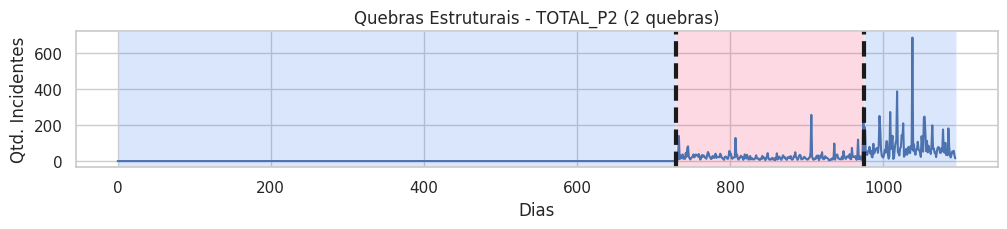


----------------------------------------
--- Analisando Coluna: TOTAL_P3 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 06/01/2025 (Índice: 735)
Quebra 2: 29/08/2025 (Índice: 970)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P3 ---

Quebra 1 na data: 06/01/2025
  Média Antes: 0.78 incidentes/dia
  Média Depois: 69.75 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 29/08/2025
  Média Antes: 69.75 incidentes/dia
  Média Depois: 198.14 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


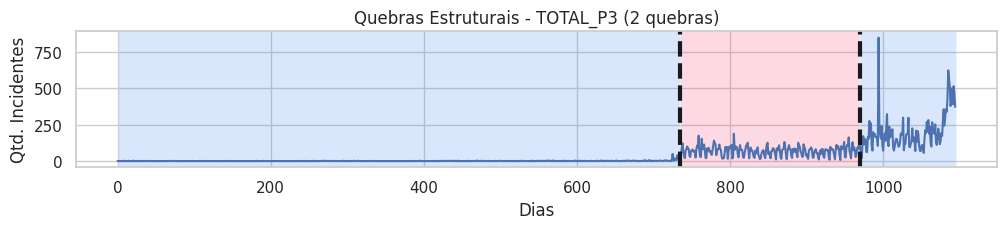


----------------------------------------
--- Analisando Coluna: TOTAL_P4 ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 27/12/2024 (Índice: 725)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_P4 ---

Quebra 1 na data: 27/12/2024
  Média Antes: 0.25 incidentes/dia
  Média Depois: 28.97 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 28.97 incidentes/dia
  Média Depois: 478.37 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


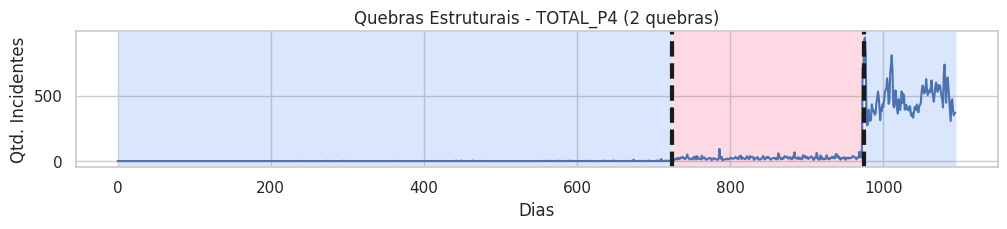


----------------------------------------
--- Analisando Coluna: TOTAL_INCIDENTES ---
----------------------------------------
Buscando exatamente 2 quebra(s)...
Quebra 1: 01/01/2025 (Índice: 730)
Quebra 2: 03/09/2025 (Índice: 975)

--- VALIDAÇÃO ESTATÍSTICA: TOTAL_INCIDENTES ---

Quebra 1 na data: 01/01/2025
  Média Antes: 1.00 incidentes/dia
  Média Depois: 124.14 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).

Quebra 2 na data: 03/09/2025
  Média Antes: 124.14 incidentes/dia
  Média Depois: 761.63 incidentes/dia
  P-Valor: 0.0000
  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).


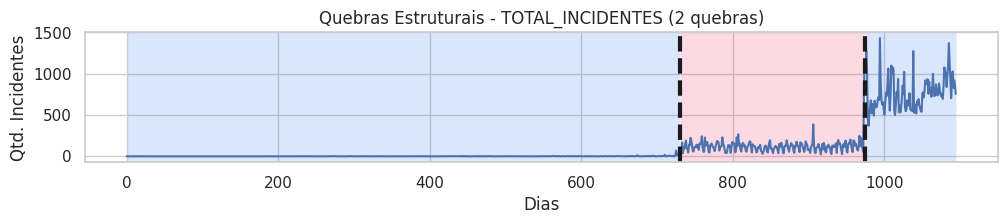

In [141]:
def encontrar_quebras_exatas(df, coluna_data, coluna_valor, n_quebras, min_tamanho=30):
    """
    Encontra um número exato de quebras estruturais em uma série temporal.
    min_tamanho garante que nenhuma quebra ocorra muito perto do fim ou início.
    """
    df_ordenado = df.sort_values(coluna_data).reset_index(drop=True)

    sinal = df_ordenado[coluna_valor].values

    # Algoritmo Dynp (Programação Dinâmica) buscando tamanho mínimo de patamar
    modelo = rpt.Dynp(model="rbf", min_size=min_tamanho).fit(sinal)

    # Prevemos usando o número EXATO de quebras (n_bkps)
    pontos_de_mudanca = modelo.predict(n_bkps=n_quebras)

    # Extraindo índices e datas
    indices_quebra = pontos_de_mudanca[:-1]
    datas_quebra = [df_ordenado[coluna_data].iloc[idx] for idx in indices_quebra]

    return datas_quebra, indices_quebra, sinal, pontos_de_mudanca

# Mapeamento do nome exato da coluna para o número de quebras observadas
config_quebras = {
    'total_p2': 2,
    'total_p3': 2,
    'total_p4': 2,
    'total_incidentes': 2  # Visão geral
}

for coluna, num_quebras_desejadas in config_quebras.items():
  print(f"\n{'-'*40}")
  print(f"--- Analisando Coluna: {coluna.upper()} ---")
  print(f"{'-'*40}")

  datas, indices, sinal, pts = encontrar_quebras_exatas(
      df=df_diario,
      coluna_data='data',
      coluna_valor=coluna,
      n_quebras=num_quebras_desejadas,
      min_tamanho=45
  )

  print(f"Buscando exatamente {num_quebras_desejadas} quebra(s)...")
  for i, data in enumerate(datas, start=1):
      print(f"Quebra {i}: {data.strftime('%d/%m/%Y')} (Índice: {indices[i-1]})")

  print(f"\n--- VALIDAÇÃO ESTATÍSTICA: {coluna.upper()} ---")

  # Adicionamos o índice 0 no início para facilitar o fatiamento dos blocos
  indices_fatiamento = [0] + indices + [len(sinal)]

  for i in range(len(indices)):
      # Definindo onde começa e termina o Bloco A (Antes) e o Bloco B (Depois)
      inicio_bloco_a = indices_fatiamento[i]
      fim_bloco_a = indices_fatiamento[i+1]
      fim_bloco_b = indices_fatiamento[i+2]

      bloco_a = sinal[inicio_bloco_a:fim_bloco_a]
      bloco_b = sinal[fim_bloco_a:fim_bloco_b]

      # Calculando as médias para visão de negócio
      media_a = np.mean(bloco_a)
      media_b = np.mean(bloco_b)

      # Aplicando o Teste de Mann-Whitney (melhor que Teste T para contagens)
      estatistica, p_valor = stats.mannwhitneyu(bloco_a, bloco_b, alternative='two-sided')

      print(f"\nQuebra {i+1} na data: {datas[i].strftime('%d/%m/%Y')}")
      print(f"  Média Antes: {media_a:.2f} incidentes/dia")
      print(f"  Média Depois: {media_b:.2f} incidentes/dia")
      print(f"  P-Valor: {p_valor:.4f}")

      # Interpretando o resultado estatístico (considerando alfa de 5%)
      if p_valor < 0.05:
          print("  Conclusão: ✅ Quebra ESTATISTICAMENTE VÁLIDA (Mudança real de patamar).")
      else:
          print("  Conclusão: ❌ Quebra INVÁLIDA / RUÍDO (As médias não são estatisticamente diferentes).")

  # Plotando os resultados
  fig, ax = rpt.display(sinal, pts, pts)
  plt.title(f"Quebras Estruturais - {coluna.upper()} ({num_quebras_desejadas} quebras)")
  plt.xlabel("Dias")
  plt.ylabel("Qtd. Incidentes")
  plt.show()

In [142]:
# Quebras escolhidas para análise de comportamento do target
q1 = "2025-01-01"
q2 = "2025-09-01"

In [143]:
# Criando o filtro de quebras pelo total de incidentes
def filtro_comportamentos(df, coluna_data, q1, q2):
    filtro_c1 = df[coluna_data] < pd.to_datetime(q1)
    filtro_c2 = ((df[coluna_data] >= pd.to_datetime(q1)) & (df[coluna_data] < pd.to_datetime(q2)))
    filtro_c3 = df[coluna_data] >= pd.to_datetime(q2)
    return [filtro_c1, filtro_c2, filtro_c3]
valores = [1, 2, 3]
df_diario['comportamento'] = np.select(filtro_comportamentos(df_diario, "data", q1, q2), valores, default=0)
df['comportamento'] = np.select(filtro_comportamentos(df, "data", q1, q2), valores, default=0)

# Contagem de dias por comportamento
contagem_dias_comportamento = df_diario.groupby('comportamento')['data'].count().reset_index()
contagem_dias_comportamento.columns = ['comportamento', 'total_dias']
contagem_dias_comportamento
# Transformação de contagem_dias_comportamento em dicionário para mapeamento
mapa_dias_comportamento = contagem_dias_comportamento.set_index('comportamento')['total_dias'].to_dict()
mapa_dias_comportamento

{1: 730, 2: 243, 3: 122}

### Comparação dos Comportamentos da Variável Target

In [144]:
# Calculando a contagem de incidentes e dias por comportamento
comparacao_comportamento = df_diario.groupby('comportamento').agg(
    total_incidentes=('total_incidentes', 'sum'),
    total_dias=('data', 'count')
)
comparacao_comportamento['media_incidentes_por_dia'] = comparacao_comportamento['total_incidentes'] / comparacao_comportamento['total_dias']
comparacao_comportamento['percentual_incidentes'] = (comparacao_comportamento['total_incidentes'] / comparacao_comportamento['total_incidentes'].sum()) * 100
comparacao_comportamento.head()

,total_incidentes,total_dias,media_incidentes_por_dia,percentual_incidentes
comportamento,,,,
1,732,730,1.002740,0.597341
2,28388,243,116.823045,23.165746
3,93423,122,765.762295,76.236913


###### Gráfico: Distribuição de frequência de incidentes por dia

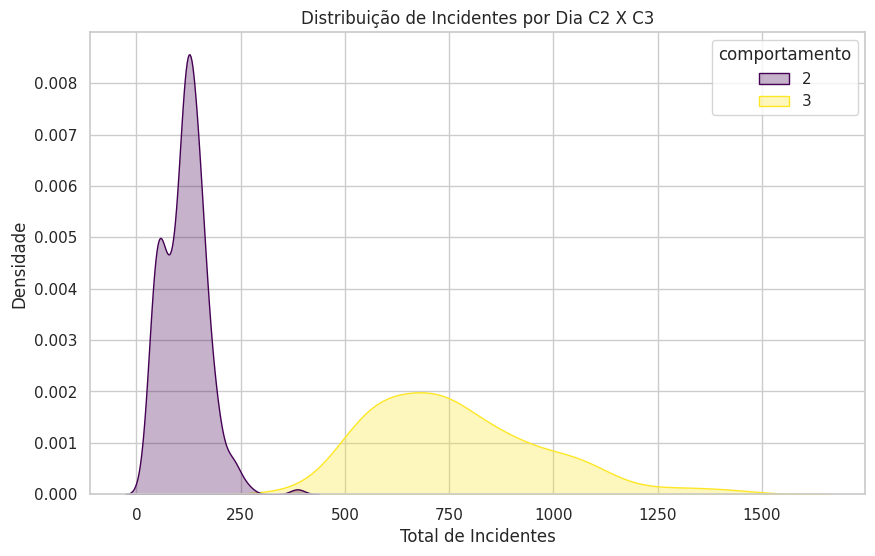

In [145]:
# Incidentes X Período
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_diario[df_diario['comportamento']>1],
    x="total_incidentes",
    hue="comportamento",
    fill=True,
    common_norm=False,
    palette="viridis",
    alpha=0.3
)

plt.title("Distribuição de Incidentes por Dia C2 X C3")
plt.xlabel("Total de Incidentes")
plt.ylabel("Densidade")
plt.show()

###### Gráfico: Incidentes por Mês

In [146]:
incidentes_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_incidentes=('total_incidentes', 'sum')
)

incidentes_por_mes_C1 = df_diario.loc[df_diario['comportamento'] == 1].groupby('ano_mes').agg(
    total_incidentes=('total_incidentes', 'sum')
)

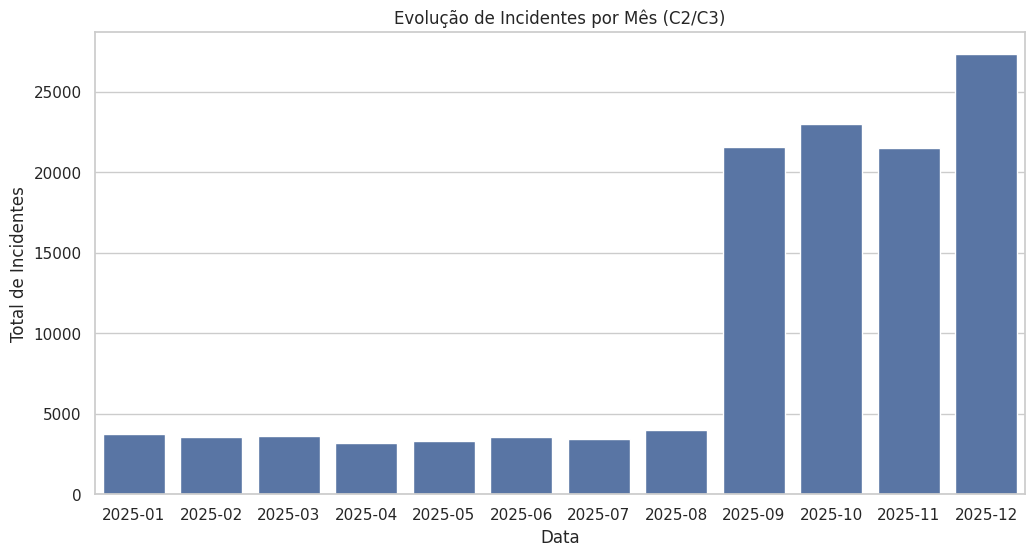

In [147]:
# Gráfico de número de incidentes por mês
plt.figure(figsize=(12, 6))
sns.barplot(data=incidentes_por_mes, x=incidentes_por_mes.index, y='total_incidentes')
plt.title("Evolução de Incidentes por Mês (C2/C3)")
plt.xlabel("Data")
plt.ylabel("Total de Incidentes")
plt.show()

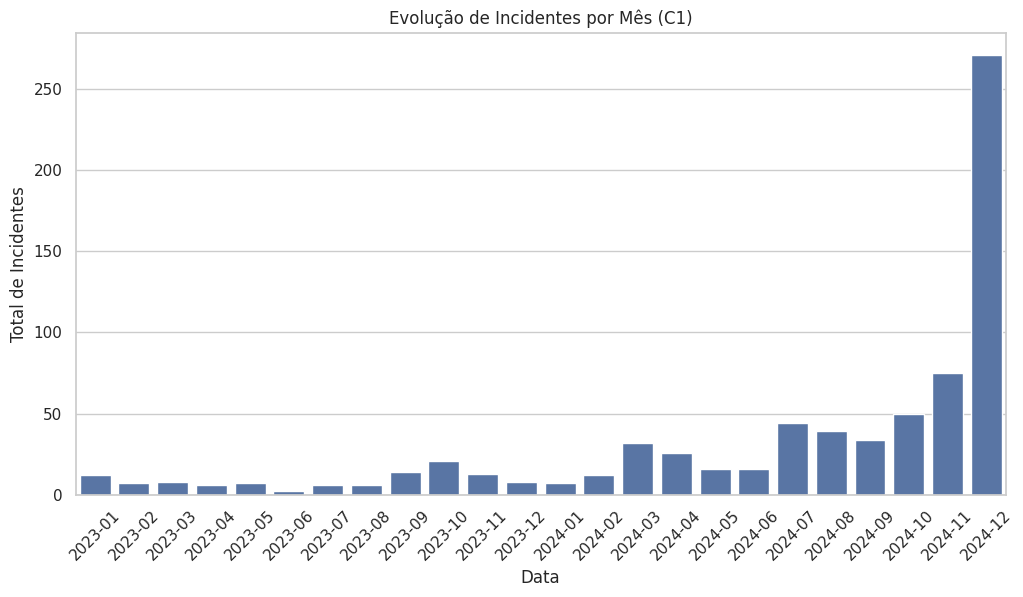

In [148]:
# Gráfico de número de incidentes por mês
plt.figure(figsize=(12, 6))
sns.barplot(data=incidentes_por_mes_C1, x=incidentes_por_mes_C1.index, y='total_incidentes')
plt.title("Evolução de Incidentes por Mês (C1)")
plt.xlabel("Data")
plt.ylabel("Total de Incidentes")
plt.xticks(rotation=45)
plt.show()

#### Comparando Sazonalidade
Foi realizada a comparação de dia util e final de semana/ feriado, e também a de dias da semana. Não foram realizadas análises de mês e trimestre, pois não há como comparar os dois de forma justa.

###### Gráfico: Comparação de Crescimento de Incidente (FNDS e Feriado X Dia Útil)

Tabela de Crescimento (Razão entre C3 e C2):


comportamento,2,3,fator_crescimento
tipo_dia,,,
dia_util,141.806061,807.267442,5.69
fnds_feriado,63.974359,666.611111,10.42


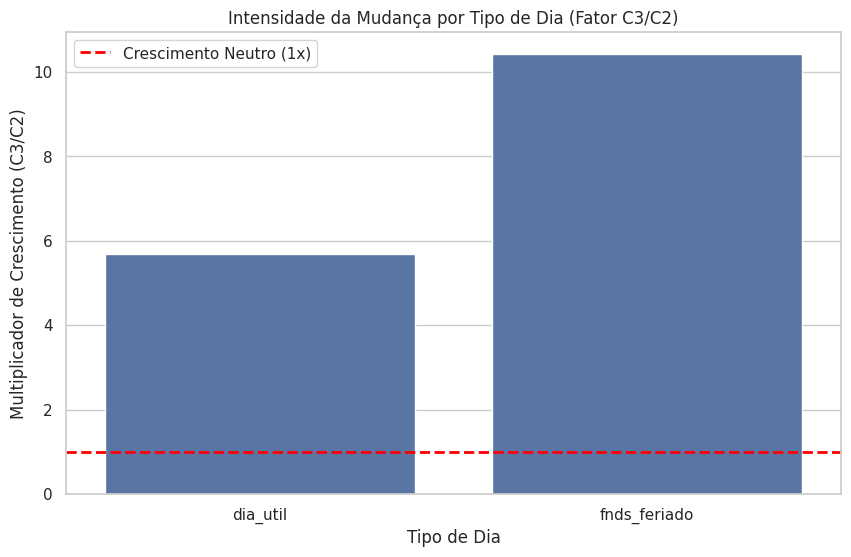

In [149]:
# Comparação Final de Semana X Feriado
df_agrupado = df_diario.groupby(['comportamento', 'tipo_dia', 'data'])['total_incidentes'].sum().reset_index()
df_taxa = df_agrupado.groupby(['comportamento', 'tipo_dia'])['total_incidentes'].mean().reset_index()
df_pivot = df_taxa[df_taxa['comportamento'].isin([2, 3])].pivot(
    index='tipo_dia', columns='comportamento', values='total_incidentes'
)
df_pivot['fator_crescimento'] = round((df_pivot[3] / df_pivot[2]), 2)
print("Tabela de Crescimento (Razão entre C3 e C2):")
display(df_pivot)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_pivot.index,
    y=df_pivot['fator_crescimento'],
)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')

plt.title("Intensidade da Mudança por Tipo de Dia (Fator C3/C2)")
plt.ylabel("Multiplicador de Crescimento (C3/C2)")
plt.xlabel("Tipo de Dia")
plt.legend()
plt.show()

###### Gráfico: Comparação de Crescimento de Incidentes por Dia da Semana

Fator de Crescimento por Dia da Semana (C3 em relação a C2):


comportamento,2,3,fator_crescimento
Qui,159.727273,781.066667,4.89
Qua,150.757576,819.666667,5.44
Ter,138.757576,817.333333,5.89
Seg,135.687500,806.055556,5.94
Sex,124.441176,807.882353,6.49
Sáb,76.735294,693.500000,9.04
Dom,49.714286,672.285714,13.52


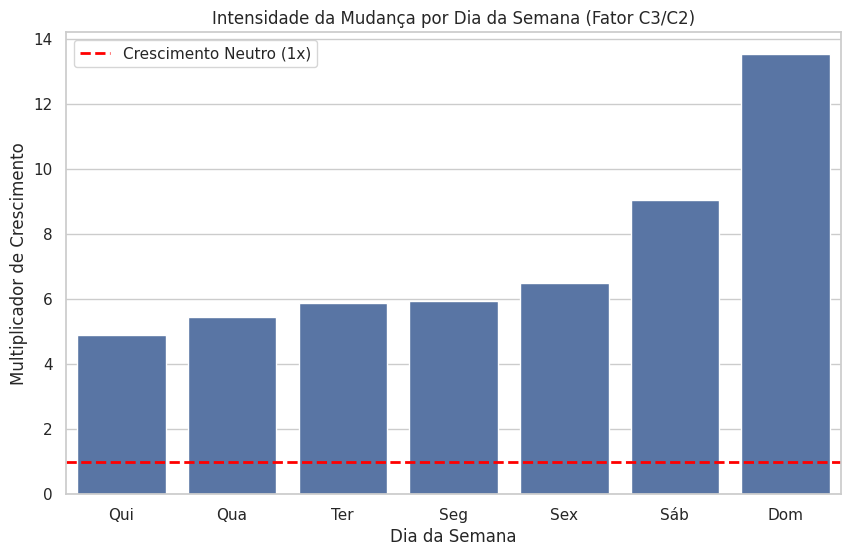

In [150]:
# Comparando dias da semana (removendo feriados)
df_uteis = df_diario[(df_diario['comportamento'].isin([2, 3])) & (df_diario['feriado'] == 0)].copy()
df_taxa_uteis = df_uteis.groupby(['comportamento', 'dia_semana'])['total_incidentes'].mean().reset_index()
df_pivot_uteis = df_taxa_uteis.pivot(index='dia_semana', columns='comportamento', values='total_incidentes')
df_pivot_uteis['fator_crescimento'] = round((df_pivot_uteis[3] / df_pivot_uteis[2]), 2)
df_pivot_uteis.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df_pivot_uteis = df_pivot_uteis.sort_values("fator_crescimento", ascending=True)
print("Fator de Crescimento por Dia da Semana (C3 em relação a C2):")
display(df_pivot_uteis)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_pivot_uteis.index,
    y=df_pivot_uteis['fator_crescimento']
)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')
plt.title("Intensidade da Mudança por Dia da Semana (Fator C3/C2)")
plt.ylabel("Multiplicador de Crescimento")
plt.xlabel("Dia da Semana")
plt.legend()
plt.show()

###### Gráfico: Comparação de Crescimento de incidentes por turno (C3/C2)

Tabela de Crescimento por Turno (Razão entre C3 e C2):


comportamento,2,3,fator_crescimento
turno,,,
inc_tarde,41.004115,189.704918,4.63
inc_manha,32.407407,205.442623,6.34
inc_noite,24.300412,181.631148,7.47
inc_madrugada,19.111111,188.983607,9.89


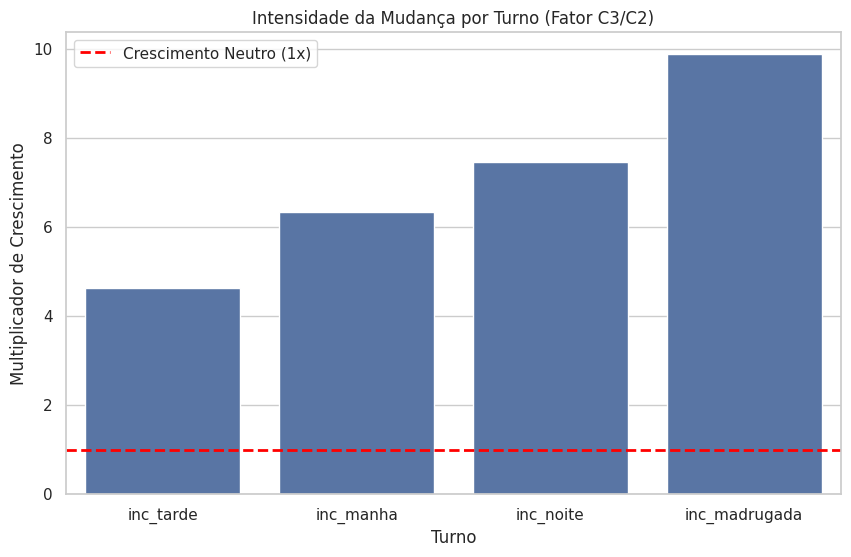

In [151]:
# Comparação por Turno
df_melted = df_diario.melt(
    id_vars=['data', 'comportamento'],
    value_vars=['inc_madrugada', 'inc_manha', 'inc_tarde', 'inc_noite'],
    var_name='turno',
    value_name='incidentes'
)
df_taxa = df_melted.groupby(['comportamento', 'turno'])['incidentes'].mean().reset_index()
df_pivot = df_taxa[df_taxa['comportamento'].isin([2, 3])].pivot(
    index='turno', columns='comportamento', values='incidentes'
)
df_pivot['fator_crescimento'] = round((df_pivot[3] / df_pivot[2]), 2)
df_pivot = df_pivot.sort_values("fator_crescimento", ascending=True)
print("Tabela de Crescimento por Turno (Razão entre C3 e C2):")
display(df_pivot)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_pivot.index,
    y=df_pivot['fator_crescimento']
)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')
plt.title("Intensidade da Mudança por Turno (Fator C3/C2)")
plt.ylabel("Multiplicador de Crescimento")
plt.xlabel("Turno")
plt.legend()
plt.show()

###### Gráfico: Comparação de Crescimento de Incidentes Horário Comercial X Horário Não Comercial (C3/C2)

Tabela de Crescimento Horário Comercial X Não Comercial (Razão entre C3 e C2):


comportamento,2,3,fator_crescimento
horario,,,
inc_hor_com,73.008230,362.844262,4.97
inc_fora_hor_com,43.814815,402.918033,9.20


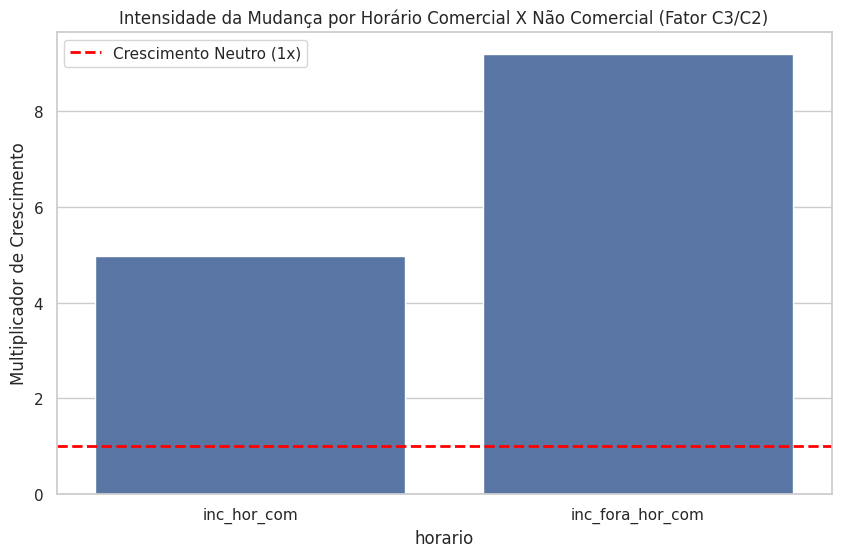

In [152]:
# Horário comercial X Horário não comercial
df_melted = df_diario.melt(
    id_vars=['data', 'comportamento'],
    value_vars=['inc_hor_com', 'inc_fora_hor_com'],
    var_name='horario',
    value_name='incidentes'
)
df_taxa = df_melted.groupby(['comportamento', 'horario'])['incidentes'].mean().reset_index()
df_pivot = df_taxa[df_taxa['comportamento'].isin([2, 3])].pivot(
    index='horario', columns='comportamento', values='incidentes'
)
df_pivot['fator_crescimento'] = round((df_pivot[3] / df_pivot[2]), 2)
df_pivot = df_pivot.sort_values("fator_crescimento", ascending=True)
print("Tabela de Crescimento Horário Comercial X Não Comercial (Razão entre C3 e C2):")
display(df_pivot)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_pivot.index,
    y=df_pivot['fator_crescimento']
)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Crescimento Neutro (1x)')
plt.title("Intensidade da Mudança por Horário Comercial X Não Comercial (Fator C3/C2)")
plt.ylabel("Multiplicador de Crescimento")
plt.legend()
plt.show()

#### Comparações a partir de dados categoricos

In [153]:
# Mapeamento das colunas categóricas
stats_data = []

for col_name in colunas_categoricas:
    nulls    = df[col_name].isna().sum()
    distintos = df[col_name].nunique()
    pct_nulls = round(nulls / total_registros * 100, 2) if total_registros > 0 else 0.0
    stats_data.append({
        "coluna": col_name,
        "total_registros": total_registros,
        "distintos": distintos,
        "nulos": int(nulls),
        "pct_nulls": pct_nulls,
    })

df_info_cat = pd.DataFrame(stats_data).sort_values(["nulos","distintos"]).reset_index(drop=True)
display(df_info_cat)

,coluna,total_registros,distintos,nulos,pct_nulls
0,Aberto por,122543,2,0,0.00
1,Status,122543,4,0,0.00
2,Prioridade,122543,5,0,0.00
3,Grupo designado,122543,17,0,0.00
4,Descrição Resumida,122543,17787,0,0.00
5,Item de configuração,122543,9171,1780,1.45
6,Categoria,122543,141,77719,63.42
7,Subcategoria,122543,447,77720,63.42
8,Produto,122543,51,77935,63.60
9,Solução,122543,2,107243,87.51


##### Coluna ""Prioridade"

In [154]:
prioridades = df.groupby("Prioridade").agg(
    total_incidentes=('Número', 'count'), # total de incidentes por prioridade
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()) # total de incidentes no comportamento 3
).reset_index()

prioridades['pct_geral'] = round((prioridades['total_incidentes']/total_registros) *100, 2)
prioridades['pct_inc_c1'] = round((prioridades['total_incidentes_c1'] / prioridades['total_incidentes_c1'].sum() ) * 100, 2)
prioridades['pct_inc_c2'] = round((prioridades['total_incidentes_c2'] / prioridades['total_incidentes_c2'].sum() ) * 100, 2)
prioridades['pct_inc_c3'] = round((prioridades['total_incidentes_c3'] / prioridades['total_incidentes_c3'].sum() ) * 100, 2)

prioridades.head()

,Prioridade,total_incidentes,total_incidentes_c1,total_incidentes_c2,total_incidentes_c3,pct_geral,pct_inc_c1,pct_inc_c2,pct_inc_c3
0,1 - Crítica,1,0,1,0,0.00,0.00,0.00,0.00
1,2 - Alta,15649,4,5640,10005,12.77,0.55,19.87,10.71
2,3 - Média,41732,472,16662,24598,34.05,64.48,58.69,26.33
3,4 - Baixa,64828,248,5780,58800,52.90,33.88,20.36,62.94
4,5 - Muito Baixa,333,8,305,20,0.27,1.09,1.07,0.02


###### Gráfico: Representatividade de Prioridades por Período

In [155]:
# Definição das cores para cada prioridade (as que você escolheu)
mapa_cores = {
    '2 - Alta': '#EF553B',   # Um vermelho vibrante do Plotly
    '3 - Média': '#FF9F43',  # Laranja
    '4 - Baixa': '#FECB52'   # Amarelo
}

fig = go.Figure()

for prioridade in ['2 - Alta', '3 - Média', '4 - Baixa']:
    # Refatoração: Filtra a linha da prioridade uma única vez.
    linha_prioridade = prioridades.loc[prioridades['Prioridade'] == prioridade]

    # Extrai os valores direto das colunas da linha filtrada
    valores_y = [
        linha_prioridade['pct_inc_c1'].values[0],
        linha_prioridade['pct_inc_c2'].values[0],
        linha_prioridade['pct_inc_c3'].values[0]
    ]

    fig.add_trace(go.Scatter(
        x=['C1', 'C2', 'C3'],
        y=valores_y,
        mode='lines+markers+text',  # Adicionado 'text' para mostrar os valores
        name=prioridade,

        # Aplicando a cor customizada na linha e no marcador
        line=dict(color=mapa_cores[prioridade], width=3),
        marker=dict(size=10, color=mapa_cores[prioridade]),

        # Formatação do texto (rótulo) sobre o ponto
        text=[f'{v:.1f}%' for v in valores_y], # Ex: "20.5%"
        textposition="top center",
        textfont=dict(size=12, color=mapa_cores[prioridade]) # Texto na cor da linha
    ))

# --- MELHORIAS VISUAIS NO LAYOUT ---
fig.update_layout(
    title=dict(
        text='<b>Distribuição Percentual de Incidentes por Comportamento e Prioridade</b>',
        x=0.5, # Centraliza o título
        font=dict(size=22)
    ),
    xaxis=dict(
        title='<b>Comportamento</b>',
        titlefont=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title='<b>Percentual de Incidentes (%)</b>',
        titlefont=dict(size=16),
        ticksuffix='%', # Adiciona '%' nos números do eixo Y
        showgrid=False,  # Remove as linhas de grade horizontais
        tickfont=dict(size=14)
    ),
    legend=dict(
        title='<b>Prioridade:</b>',
        font=dict(size=13),
        orientation="h", # Coloca a legenda na horizontal
        yanchor="bottom",
        y=1.02, # Posição um pouco acima do gráfico
        xanchor="right",
        x=1
    ),
    template='plotly_white', # Fundo branco para visual limpo
    margin=dict(l=60, r=60, t=100, b=60) # Ajusta margens para título e legenda
)

fig.show()

Nesse gráfico, podemos observer que o número geral de incidentes por prioridade mudou muito entre os comportamentos. Nos comportamentos C1 e C2, a prioridade mais representativa era "P3", e a partir do comportamento C3, parece que houve uma repriorização de incidentes, e as proporções se assemelharam mais ao comportamento "esperado" (quanto menor a prioridde, maior a taxa de incidentes), com P4 liderando (63%), P3 em segundo lugar e P2 (26%) em terceiro (11%).

##### Coluna "Aberto por"

In [156]:
aberto_por = df.groupby("Aberto por").agg(
    total_incidentes=('Número', 'count'), # total de incidentes por prioridade
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()) # total de incidentes no comportamento 3
).reset_index()
aberto_por['pct_geral'] = round((aberto_por['total_incidentes']/total_registros) *100, 2)
aberto_por['pct_inc_c1'] = round((aberto_por['total_incidentes_c1'] / aberto_por['total_incidentes_c1'].sum() ) * 100, 2)
aberto_por['pct_inc_c2'] = round((aberto_por['total_incidentes_c2'] / aberto_por['total_incidentes_c2'].sum() ) * 100, 2)
aberto_por['pct_inc_c3'] = round((aberto_por['total_incidentes_c3'] / aberto_por['total_incidentes_c3'].sum() ) * 100, 2)
aberto_por.head()

,Aberto por,total_incidentes,total_incidentes_c1,total_incidentes_c2,total_incidentes_c3,pct_geral,pct_inc_c1,pct_inc_c2,pct_inc_c3
0,Manual,18244,539,12805,4900,14.89,73.63,45.11,5.24
1,Monitoramento,104299,193,15583,88523,85.11,26.37,54.89,94.76


##### Coluna "Status"

In [157]:
status = df.groupby("Status").agg(
    total_incidentes=('Número', 'count'), # total de incidentes por prioridade
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()) # total de incidentes no comportamento 3
).reset_index()
status['pct_geral'] = round((status['total_incidentes']/total_registros) *100, 2)
status['pct_inc_c1'] = round((status['total_incidentes_c1'] / status['total_incidentes_c1'].sum() ) * 100, 2)
status['pct_inc_c2'] = round((status['total_incidentes_c2'] / status['total_incidentes_c2'].sum() ) * 100, 2)
status['pct_inc_c3'] = round((status['total_incidentes_c3'] / status['total_incidentes_c3'].sum() ) * 100, 2)
status.head()


,Status,total_incidentes,total_incidentes_c1,total_incidentes_c2,total_incidentes_c3,pct_geral,pct_inc_c1,pct_inc_c2,pct_inc_c3
0,Aguardando Problema,1,0,1,0,0.00,0.00,0.00,0.00
1,Encerrado,15339,73,10058,5208,12.52,9.97,35.43,5.57
2,Encerrado Automaticamente,26830,656,18247,7927,21.89,89.62,64.28,8.49
3,Sem Intervenção,80373,3,82,80288,65.59,0.41,0.29,85.94


##### Coluna "Grupo designado"

A coluna grupo designado revela uma das formas pelas quais a própria locaweb "clusteriza" os incidentes. Os times possuem diferentes stacks para resolver diferentes tipos de problema, em diferentes prioridades, etc. Procurar entender como os times evoluíram ao longo do tempo pode nos contar uma história de como a locaweb lidou com o aumento de incidentes (o que também pode nos dar alguma pista dos tipos de incidentes que aumentaram). Por isso, é crucial entender o que diferem os times. A principal pergunta a ser respondida é : Por que cada incidente vai para cada time?

Aspectos que podemos analisar:
- Geral: qual era o ranking de times por total de incidentes resolvidos em cada comportamento?
- Prioridade: os times atendem mais ou menos a mesma proporção de prioridades? ao longo dos comportamentos, os times mudaram sua atuação, de acordo com o comportamento geral?
- Diversidade: quantos itens de configuração/categorias/produtos cada time atende (em relação ao número total de incidentes do time)? isso mudou ao longo dos comportamentos?
- Sazonalidade: quais os horários que os times atuam? (tem times que parecem ser plantonistas ou algo assim?)

In [158]:
grupos_designados = df.groupby('Grupo designado').agg(
    total_incidentes=('Número', 'count'), # total de incidentes por grupo designado

    # Para entender quais times estavam ativos em cada período de comportamento
    data_minima=('data', 'min'), # primeira data de incidente para cada grupo designado
    data_maxima=('data', 'max'), # última data de incidente para cada grupo designado

    # Para entender a diversidade de produtos/categorias/subcategorias/itens de configuração atendidos por grupo designado
    cat_distintos=('Categoria', 'nunique'), # total de categorias distintas por grupo designado
    cat_distintos_c1=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Categoria'].nunique()), # total de categorias distintas no comportamento 1
    cat_distintos_c2=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Categoria'].nunique()), # total de categorias distintas no comportamento 2
    cat_distintos_c3=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Categoria'].nunique()), # total de categorias distintas no comportamento 3
    prod_distintos=('Produto', 'nunique'), # total de produtos distintos por grupo designado
    prod_distintos_c1=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Produto'].nunique()), # total de produtos distintos no comportamento 1
    prod_distintos_c2=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Produto'].nunique()), # total de produtos distintos no comportamento 2
    prod_distintos_c3=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Produto'].nunique()), # total de produtos distintos no comportamento 3
    ic_distintos=('Item de configuração', 'nunique'), # total de items de configuração distintos por grupo designado
    ic_distintos_c1=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 1
    ic_distintos_c2=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 2
    ic_distintos_c3=('Item de configuração', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Item de configuração'].nunique()), # total de items de configuração distintos no comportamento 3

    # Para entender a quantidade de incidentes por comportamento e prioridade
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()), # total de incidentes no comportamento 3

    inc_p1=('Prioridade_Ordinal', lambda x: (x == 1).sum()), # total de incidentes de prioridade 1
    inc_p2=('Prioridade_Ordinal', lambda x: (x == 2).sum()), # total de incidentes de prioridade 2
    inc_p3=('Prioridade_Ordinal', lambda x: (x == 3).sum()), # total de incidentes de prioridade 3
    inc_p4=('Prioridade_Ordinal', lambda x: (x == 4).sum()), # total de incidentes de prioridade 4
    inc_p5=('Prioridade_Ordinal', lambda x: (x == 5).sum()), # total de incidentes de prioridade 5

    inc_p1_c1=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 1 no comportamento 1
    inc_p2_c1=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 2 no comportamento 1
    inc_p3_c1=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 3 no comportamento 1
    inc_p4_c1=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 4 no comportamento 1
    inc_p5_c1=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 5 no comportamento 1

    inc_p1_c2=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 1 no comportamento 2
    inc_p2_c2=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 2 no comportamento 2
    inc_p3_c2=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 3 no comportamento 2
    inc_p4_c2=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 4 no comportamento 2
    inc_p5_c2=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 5 no comportamento 2

    inc_p1_c3=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 1 no comportamento 3
    inc_p2_c3=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 2 no comportamento 3
    inc_p3_c3=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 3 no comportamento 3
    inc_p4_c3=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 4 no comportamento 3
    inc_p5_c3=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 3)).sum()) # total de incidentes de prioridade 5 no comportamento 3
).reset_index()

grupos_designados = grupos_designados.sort_values(by='total_incidentes', ascending=False)
grupos_designados['pct_incidentes_geral'] = round((grupos_designados['total_incidentes'] / total_registros), 4) * 100 # percentual de incidentes do grupo designado em relação ao total de incidentes

# Percentual de incidentes por comportamento em relação ao total de incidentes do periodo do comportamento (C1, C2, C3)
# Para entender a nível geral se houve mudança na atuação de cada time (ex: Time x resolvia mais incidentes que time y)
# Essa análise pode ajudar a descobrir quais os tipos específicos de incidentes que cresceram tanto
grupos_designados['pct_inc_c1_geral'] = round((grupos_designados['total_incidentes_c1'] / grupos_designados['total_incidentes_c1'].sum()), 4) * 100
grupos_designados['pct_inc_c2_geral'] = round((grupos_designados['total_incidentes_c2'] / grupos_designados['total_incidentes_c2'].sum()), 4) * 100
grupos_designados['pct_inc_c3_geral'] = round((grupos_designados['total_incidentes_c3'] / grupos_designados['total_incidentes_c3'].sum()), 4) * 100


# De todos os incidentes resolvidos pelo time, quantos % eram da prioridade x
# Para entender a nível individual se houve mudança na atuação de cada time (ex: Time x passou a resolver mais P3 a partir de C3)

grupos_designados.head(17)

,Grupo designado,total_incidentes,data_minima,data_maxima,cat_distintos,cat_distintos_c1,cat_distintos_c2,cat_distintos_c3,prod_distintos,prod_distintos_c1,...,inc_p5_c2,inc_p1_c3,inc_p2_c3,inc_p3_c3,inc_p4_c3,inc_p5_c3,pct_incidentes_geral,pct_inc_c1_geral,pct_inc_c2_geral,pct_inc_c3_geral
13,Team14,92775,2023-01-09,2025-12-31,73,24,67,59,29,14,...,227,0,7793,16718,57192,14,75.71,13.93,38.59,87.47
10,Team11,9790,2023-01-11,2025-12-30,66,17,60,45,35,14,...,38,0,15,2198,185,0,7.99,8.47,25.82,2.57
4,Team05,9276,2023-01-30,2025-12-30,49,23,44,34,20,8,...,3,0,1236,2556,118,0,7.57,42.90,17.80,4.19
8,Team09,3425,2023-02-09,2025-12-31,65,23,56,53,28,12,...,21,0,300,501,348,3,2.79,23.22,7.41,1.23
11,Team12,2173,2024-03-19,2025-12-31,49,5,39,29,29,4,...,2,0,292,1197,5,0,1.77,1.09,2.36,1.60
2,Team03,1306,2024-11-19,2025-12-31,52,2,44,34,25,3,...,4,0,106,119,534,0,1.07,0.41,1.92,0.81
9,Team10,1172,2024-12-24,2025-12-31,12,1,10,4,10,1,...,0,0,128,867,49,0,0.96,0.27,0.44,1.12
16,Team17,743,2023-05-20,2025-12-26,35,7,32,23,17,4,...,3,0,51,136,56,0,0.61,3.01,1.68,0.26
1,Team02,579,2023-08-30,2025-12-30,32,2,26,21,15,1,...,0,0,34,54,176,0,0.47,0.55,1.10,0.28
0,Team01,306,2024-12-29,2025-12-26,25,1,24,13,10,1,...,6,0,1,91,21,3,0.25,0.14,0.67,0.12


###### Gráfico: Atuação dos Times em cada Comportamento

In [159]:
df_plot = grupos_designados[['Grupo designado', 'pct_inc_c1_geral', 'pct_inc_c2_geral', 'pct_inc_c3_geral']].copy()
times_destaque = ["Team14", "Team11", "Team05", "Team09"]
linha_outros = pd.DataFrame({
    'Grupo designado': ['Outros'],
    'pct_inc_c1_geral': [grupos_designados.loc[~grupos_designados['Grupo designado'].isin(times_destaque), 'pct_inc_c1_geral'].sum()],
    'pct_inc_c2_geral': [grupos_designados.loc[~grupos_designados['Grupo designado'].isin(times_destaque), 'pct_inc_c2_geral'].sum()],
    'pct_inc_c3_geral': [grupos_designados.loc[~grupos_designados['Grupo designado'].isin(times_destaque), 'pct_inc_c3_geral'].sum()]
})
df_plot = df_plot.loc[df_plot['Grupo designado'].isin(times_destaque)]
df_plot = pd.concat([df_plot[df_plot['Grupo designado'].isin(times_destaque)], linha_outros], ignore_index=True)

In [160]:
fig = go.Figure()
for equipe in df_plot['Grupo designado']:
    fig.add_trace(go.Scatter(
                              x=['C1', 'C2', 'C3'],
                              y=[df_plot.loc[df_plot['Grupo designado']==equipe, 'pct_inc_c1_geral'].values[0],
                                df_plot.loc[df_plot['Grupo designado']==equipe, 'pct_inc_c2_geral'].values[0],
                                df_plot.loc[df_plot['Grupo designado']==equipe, 'pct_inc_c3_geral'].values[0]],
                              mode='lines+markers', name=equipe
                             )
                  )
fig.show()

##### Coluna "Item de configuração"



In [161]:
# Registros em que IC é nulo
df['IC_is_null'] = df['Item de configuração'].isnull()
df_ic_nulo = df.groupby('IC_is_null').agg(
    total_incidentes=('Número', 'count'),
    total_incidentes_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    total_incidentes_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    total_incidentes_c3=('comportamento', lambda x: (x == 3).sum()), # total de incidentes no comportamento 3
    aberto_por_monitoramento=('Aberto por', lambda x: (x == 'Monitoramento').sum())
).reset_index()
df_ic_nulo['pct_geral'] = round((df_ic_nulo['total_incidentes']/total_registros) *100, 2)

df_ic_nulo.head()

,IC_is_null,total_incidentes,total_incidentes_c1,total_incidentes_c2,total_incidentes_c3,aberto_por_monitoramento,pct_geral
0,False,120763,728,28275,91760,102577,98.55
1,True,1780,4,113,1663,1722,1.45


In [162]:
itens_config = df.groupby('Item de configuração').agg(
    # Métrica de volume para entender quais itens de configuração (IC) estão mais propensos a gerar incidentes
    total_incidentes=('Número', 'count'), # total de incidentes por item de configuração
    inc_c1=('comportamento', lambda x: (x == 1).sum()), # total de incidentes no comportamento 1
    inc_c2=('comportamento', lambda x: (x == 2).sum()), # total de incidentes no comportamento 2
    inc_c3=('comportamento', lambda x: (x == 3).sum()), # total de incidentes no comportamento 3

    # Métrica temporal para entender o ciclo de vida do item de configuração (IC) e a frequência de incidentes
    data_minima=('data', 'min'), # primeira data de incidente para cada item de configuração
    data_maxima=('data', 'max'), # última data de incidente para cada item de configuração
    ciclo_vida_dias=('data', lambda x: (x.max() - x.min()).days), # total de dias ativos do item de configuração
    dias_ativos_c1=('data', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'data'].nunique()), # total de dias ativos no comportamento 1
    dias_ativos_c2=('data', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'data'].nunique()), # total de dias ativos no comportamento 2
    dias_ativos_c3=('data', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'data'].nunique()), # total de dias ativos no comportamento 3

    # Métricas de diversidade
    cat_distintos=('Categoria', 'nunique'), # total de categorias distintas por item de configuração
    cat_distintos_c1=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Categoria'].nunique()), # total de categorias distintas no comportamento 1
    cat_distintos_c2=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Categoria'].nunique()), # total de categorias distintas no comportamento 2
    cat_distintos_c3=('Categoria', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Categoria'].nunique()), # total de categorias distintas no comportamento 3
    prod_distintos=('Produto', 'nunique'), # total de produtos distintos por item de configuração
    prod_distintos_c1=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Produto'].nunique()), # total de produtos distintos no comportamento 1
    prod_distintos_c2=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Produto'].nunique()), # total de produtos distintos no comportamento 2
    prod_distintos_c3=('Produto', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Produto'].nunique()), # total de produtos distintos no comportamento 3
    times_distintos=('Grupo designado', 'nunique'), # total de times distintos por item de configuração
    times_distintos_c1=('Grupo designado', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 1], 'Grupo designado'].nunique()), # total de times distintos no comportamento 1
    times_distintos_c2=('Grupo designado', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 2], 'Grupo designado'].nunique()), # total de times distintos no comportamento 2
    times_distintos_c3=('Grupo designado', lambda x: df.loc[x.index[df.loc[x.index, 'comportamento'] == 3], 'Grupo designado'].nunique()), # total de times distintos no comportamento 3

    # Métricas de prioridade para entender a criticidade dos incidentes por item de configuração
    inc_p1_c1=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 1 no comportamento 1
    inc_p2_c1=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 2 no comportamento 1
    inc_p3_c1=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 3 no comportamento 1
    inc_p4_c1=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 4 no comportamento 1
    inc_p5_c1=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes de prioridade 5 no comportamento 1
    inc_p1_c2=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 1 no comportamento 2
    inc_p2_c2=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 2 no comportamento 2
    inc_p3_c2=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 3 no comportamento 2
    inc_p4_c2=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 4 no comportamento 2
    inc_p5_c2=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes de prioridade 5 no comportamento 2
    inc_p1_c3=('Prioridade_Ordinal', lambda x: ((x == 1) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 1 no comportamento 3
    inc_p2_c3=('Prioridade_Ordinal', lambda x: ((x == 2) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 2 no comportamento 3
    inc_p3_c3=('Prioridade_Ordinal', lambda x: ((x == 3) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 3 no comportamento 3
    inc_p4_c3=('Prioridade_Ordinal', lambda x: ((x == 4) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 4 no comportamento 3
    inc_p5_c3=('Prioridade_Ordinal', lambda x: ((x == 5) & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes de prioridade 5 no comportamento 3

    # Métricas de Abertura por Monitoramento em C1/C2/C3 para entender se o item de configuração (IC) passou a ser monitorado automáticamente ou não
    inc_aberto_monitoramento=('Aberto por', lambda x: (x == "Monitoramento").sum()), # total de incidentes do IC abertos por monitoramento
    inc_aberto_monitoramento_c1=('Aberto por', lambda x: ((x == "Monitoramento") & (df.loc[x.index, 'comportamento'] == 1)).sum()), # total de incidentes do IC abertos por monitoramento no comportamento 1
    inc_aberto_monitoramento_c2=('Aberto por', lambda x: ((x == "Monitoramento") & (df.loc[x.index, 'comportamento'] == 2)).sum()), # total de incidentes do IC abertos por monitoramento no comportamento 2
    inc_aberto_monitoramento_c3=('Aberto por', lambda x: ((x == "Monitoramento") & (df.loc[x.index, 'comportamento'] == 3)).sum()), # total de incidentes do IC abertos por monitoramento no comportamento 3

    # Métricas de Status em C1/C2/C3 para entender se o item de configuração (IC) passou a ser mais encerrado automaticamente / sem intervenção humana ou não
    inc_status_encerrado=('Status', lambda x: (x == "Encerrado").sum()), # total de incidentes do IC com status encerrado
    inc_status_encerrado_automaticamente=('Status', lambda x: (x == "Encerrado Automaticamente").sum()), # total de incidentes do IC com status encerrado automaticamente
    inc_status_encerrado_manual=('Status', lambda x: ((x == "Encerrado") & (df.loc[x.index, 'Aberto por'] != "Monitoramento")).sum())

).reset_index()

itens_config['ciclo_vida_meses'] = itens_config['ciclo_vida_dias'] / 30 # ciclo de vida do IC em meses

itens_config['pct_inc_aberto_monitoramento_c1'] = itens_config['inc_aberto_monitoramento_c1'] / itens_config['inc_c1'] * 100
itens_config['pct_inc_aberto_monitoramento_c2'] = itens_config['inc_aberto_monitoramento_c2'] / itens_config['inc_c2'] * 100
itens_config['pct_inc_aberto_monitoramento_c3'] = itens_config['inc_aberto_monitoramento_c3'] / itens_config['inc_c3'] * 100

itens_config = itens_config.fillna(0)

# Frequência - Média de incidentes por dia para cada comportamento (C1, C2, C3) | Do total de dias
for comportamento in [1, 2, 3]:
    itens_config[f'media_inc_por_dia_c{comportamento}'] = itens_config[f'inc_c{comportamento}'] / mapa_dias_comportamento[comportamento]

# Intensidade - Média de incidentes por dia ativo do item de configuração (IC) para cada comportamento (C1, C2, C3) | Dos dias em que efetivamente houve incidentes para o IC
for comportamento in [1, 2, 3]:
    itens_config[f'media_inc_por_dia_ativo_c{comportamento}'] = itens_config[f'inc_c{comportamento}'] / itens_config[f'dias_ativos_c{comportamento}']

# Métrica de Recência
itens_config['dias_desde_ultimo_incidente'] = (df_diario['data'].max() - itens_config['data_maxima']).dt.days # diferença de dias entre a última aparição do IC e a data mais recente do dataset

itens_config = itens_config.fillna(0)

itens_config = itens_config.sort_values(by='total_incidentes', ascending=False)
itens_config.head(5)

,Item de configuração,total_incidentes,inc_c1,inc_c2,inc_c3,data_minima,data_maxima,ciclo_vida_dias,dias_ativos_c1,dias_ativos_c2,...,pct_inc_aberto_monitoramento_c1,pct_inc_aberto_monitoramento_c2,pct_inc_aberto_monitoramento_c3,media_inc_por_dia_c1,media_inc_por_dia_c2,media_inc_por_dia_c3,media_inc_por_dia_ativo_c1,media_inc_por_dia_ativo_c2,media_inc_por_dia_ativo_c3,dias_desde_ultimo_incidente
13,IC00014,6069,0,0,6069,2025-09-01,2025-12-31,121,0,0,...,0.0,0.000000,100.000000,0.000000,0.000000,49.745902,0.000000,0.000000,49.745902,0
18,IC00019,4435,0,0,4435,2025-09-01,2025-12-31,121,0,0,...,0.0,0.000000,100.000000,0.000000,0.000000,36.352459,0.000000,0.000000,36.352459,0
7,IC00008,4196,0,2,4194,2025-02-06,2025-12-31,328,0,2,...,0.0,100.000000,100.000000,0.000000,0.008230,34.377049,0.000000,1.000000,35.243697,0
348,IC00349,3271,11,2599,661,2023-02-05,2025-12-29,1058,6,238,...,0.0,5.925356,6.959153,0.015068,10.695473,5.418033,1.833333,10.920168,6.544554,2
1,IC00002,3119,0,0,3119,2025-09-01,2025-12-31,121,0,0,...,0.0,0.000000,100.000000,0.000000,0.000000,25.565574,0.000000,0.000000,25.565574,0


###### Analisando o total de IC

In [163]:
itens_config[['inc_c1','inc_c2','inc_c3', 'total_incidentes']].describe()

,inc_c1,inc_c2,inc_c3,total_incidentes
count,9171.000000,9171.000000,9171.000000,9171.000000
mean,0.079381,3.083088,10.005452,13.167921
std,1.637024,32.789429,105.504076,113.533968
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000
50%,0.000000,1.000000,1.000000,2.000000
75%,0.000000,2.000000,2.000000,4.000000
max,130.000000,2599.000000,6069.000000,6069.000000


Observação: existem itens de configuração que não apareceram em todos os períodos (podem ter ocorrido em qualquer um deles). Pelo menos 25% deles só apareceu 1 vez, assim como pelo menos 25% apareceu 4 ou mais vezes.

In [164]:
for comp in [1, 2, 3]:
    col_nome = f'inc_c{comp}'
    col_outlier = f'outlier_{col_nome}'

    # Criar a coluna no dataframe principal preenchida com False (0)
    itens_config[col_outlier] = False

    # Filtrar apenas ICs com atividade
    mask_ativos = itens_config[col_nome] > 0
    df_ativos = itens_config.loc[mask_ativos, ['Item de configuração', col_nome]].copy()

    # Identificar outliers
    li, ls, series_outliers = marcar_outliers(df_ativos, col_nome)

    # Atualizar o dataframe principal
    itens_config.loc[mask_ativos, col_outlier] = series_outliers
    itens_config[col_outlier] = itens_config[col_outlier].astype(int)

    # Métricas de contagem
    total_ativos = len(df_ativos)
    total_outliers = series_outliers.sum()
    pct_outliers_count = (total_outliers / total_ativos * 100) if total_ativos > 0 else 0

    # Métricas de volume (Impacto)
    total_volume_periodo = df_ativos[col_nome].sum()
    volume_outliers = df_ativos.loc[series_outliers, col_nome].sum()
    pct_volume_impacto = (volume_outliers / total_volume_periodo * 100) if total_volume_periodo > 0 else 0

    print(f"--- Comportamento {comp} ---")
    print(f"Limite Superior: {ls:.2f}")
    print(f"ICs Outliers: {pct_outliers_count:.2f}% ({total_outliers}/{total_ativos})")
    print(f"Impacto no Volume: {pct_volume_impacto:.2f}% ({volume_outliers}/{total_volume_periodo}) dos incidentes gerados por outliers")
    print("-" * 30)

--- Comportamento 1 ---
Limite Superior: 1.00
ICs Outliers: 20.25% (64/316)
Impacto no Volume: 65.38% (476/728) dos incidentes gerados por outliers
------------------------------
--- Comportamento 2 ---
Limite Superior: 6.00
ICs Outliers: 13.50% (671/4972)
Impacto no Volume: 71.88% (20325/28275) dos incidentes gerados por outliers
------------------------------
--- Comportamento 3 ---
Limite Superior: 8.50
ICs Outliers: 16.13% (1031/6392)
Impacto no Volume: 88.65% (81348/91760) dos incidentes gerados por outliers
------------------------------


A maior parte dos incidentes é gerada por itens de configuração outliers no quesito número de incidentes...

###### Analisando Recorrência

In [165]:
# ICs com maior media de incidentes por dia ativo (C1, C2, C3) | Foco em intensidade de incidentes
itens_config[['total_incidentes','media_inc_por_dia_ativo_c1', 'media_inc_por_dia_ativo_c2', 'media_inc_por_dia_ativo_c3']].describe()

,total_incidentes,media_inc_por_dia_ativo_c1,media_inc_por_dia_ativo_c2,media_inc_por_dia_ativo_c3
count,9171.000000,9171.000000,9171.000000,9171.000000
mean,13.167921,0.038550,0.684336,0.991372
std,113.533968,0.301877,0.995747,1.782634
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,1.000000
75%,4.000000,0.000000,1.000000,1.000000
max,6069.000000,22.000000,23.000000,59.200000


###### Classificando os ICs na jornada de monitoramento

In [166]:
def classificar_jornada_completa(row):
    # Utilizando 75% como régua para separar o que é realmente focado em automação
    mon_c1 = row['pct_inc_aberto_monitoramento_c1'] >= 75
    mon_c2 = row['pct_inc_aberto_monitoramento_c2'] >= 75
    mon_c3 = row['pct_inc_aberto_monitoramento_c3'] >= 75

    # MONITORADO NATIVO ANTIGO
    # Se tiveram incidentes em C1, C2 e C3, e foi mais de 75% monitorado em todos
    # Se tiveram incidentes apenas em C1 e C2, e foi mais de 75% monitorado em ambos
    # Se tiveram incidentes apenas em C1 e C3, e foi mais de 75% monitorado em ambos
    # Se tiveram incidentes apenas em C2 e C3, e foi mais de 75% monitorado em ambos
    # Se tiveram incidentes apenas em C1, e foi mais de 75% monitorado
    # Se tiveram incidentes apenas em C2, e foi mais de 75% monitorado

    if (mon_c1 and mon_c2 and mon_c3) or \
    (mon_c1 and mon_c2 and row['inc_c3'] == 0) or \
    (mon_c1 and row['inc_c2'] == 0 and mon_c3) or \
    (row['inc_c1'] == 0 and mon_c2 and mon_c3) or \
    (mon_c1 and row['inc_c2'] == 0 and row['inc_c3'] == 0) or \
    (row['inc_c1'] == 0 and mon_c2 and row['inc_c3'] == 0):
        return 'Monitorado Nativo Antigo'

    # MONITORADO NATIVO NOVO
    # Se tiveram incidentes apenas em C3, e foi mais de 75% monitorado
    elif (row['inc_c1'] == 0 and row['inc_c2'] == 0 and mon_c3):
        return 'Monitorado Nativo Novo'

    # MAJORITARIAMENTE MANUAL
    # Se tiveram incidentes em C1, C2 e C3, e foi mais de 25% manual em todos
    # Se tiveram incidentes apenas em C1 e C2, e foi mais de 25% manual em ambos
    # Se tiveram incidentes apenas em C1 e C3, e foi mais de 25% manual em ambos
    # Se tiveram incidentes apenas em C2 e C3, e foi mais de 25% manual em ambos
    # Se tiveram incidentes apenas em C1, e foi mais de 25% manual
    # Se tiveram incidentes apenas em C2, e foi mais de 25% manual
    # Se tiveram incidentes apenas em C3, e foi mais de 25% manual
    elif ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (not mon_c1 and not mon_c2 and not mon_c3)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] == 0) and (not mon_c1 and not mon_c2)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] == 0 and row['inc_c3'] > 0) and (not mon_c1 and not mon_c3)) or \
    ((row['inc_c1'] == 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (not mon_c2 and not mon_c3)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] == 0 and row['inc_c3'] == 0) and not mon_c1) or \
    ((row['inc_c1'] == 0 and row['inc_c2'] > 0 and row['inc_c3'] == 0) and not mon_c2) or \
    ((row['inc_c1'] == 0 and row['inc_c2'] == 0 and row['inc_c3'] > 0) and not mon_c3):
        return 'Sempre mais de 25% Manual'

    # MIGRADO NO C2
    # Se tiveram incidentes em C1, C2 e C3, mas era manual em C1 e passou a ser monitorado em C2 e C3
    # Se tiveram incidentes apenas em C1 e C2, mas era manual em C1 e passou a ser monitorado em C2
    elif ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (not mon_c1 and mon_c2 and mon_c3)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] == 0) and (not mon_c1 and mon_c2)):
        return 'Migrado no C2'

    # MIGRADO NO C3
    # Se tiveram incidentes em C1, C2 e C3, mas era manual em C1 e C2 e passou a ser monitorado em C3
    # Se não tiveram incidentes em C1, mas tiveram em C2 e C3, e passou a ser monitorado em C3
    # Se não tiveram incidentes em C2, mas tiveram em C1 e C3, e era manual em C1 e passou a ser monitorado em C3
    # Se tiveram incidentes em C1, C2 e C3, era monitorado no C1, caiu para manual no C2, mas recuperou/melhorou no C3 <-- CASO NOVO
    elif ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (not mon_c1 and not mon_c2 and mon_c3)) or \
    ((row['inc_c1'] == 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (not mon_c2 and mon_c3)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] == 0 and row['inc_c3'] > 0) and (not mon_c1 and mon_c3)) or \
    ((row['inc_c1'] > 0 and row['inc_c2'] > 0 and row['inc_c3'] > 0) and (mon_c1 and not mon_c2 and mon_c3)):
        return 'Migrado no C3'

    return 'Mudança de Comportamento Inconsistente'

itens_config['jornada_monitoramento'] = itens_config.apply(classificar_jornada_completa, axis=1)

resumo_final = itens_config.groupby('jornada_monitoramento').agg(
    total_ics=('Item de configuração', 'count'),
    volume_incidentes_total=('total_incidentes', 'sum'),
    media_incidentes_por_ic=('total_incidentes', 'mean'),
).sort_values(by='total_ics', ascending=False)

# Adicionando a % do volume total
resumo_final['pct_volume_do_total'] = (resumo_final['volume_incidentes_total'] / resumo_final['volume_incidentes_total'].sum()) * 100

display(resumo_final)

,total_ics,volume_incidentes_total,media_incidentes_por_ic,pct_volume_do_total
jornada_monitoramento,,,,
Monitorado Nativo Novo,3510,37333,10.636182,30.914270
Monitorado Nativo Antigo,2793,47984,17.180093,39.734024
Sempre mais de 25% Manual,2095,16503,7.877327,13.665609
Migrado no C3,625,17519,28.030400,14.506927
Mudança de Comportamento Inconsistente,116,951,8.198276,0.787493
Migrado no C2,32,473,14.781250,0.391676


In [167]:
itens_config.loc[itens_config['jornada_monitoramento'] == 'Mudança de Comportamento Inconsistente', ['Item de configuração', 'inc_c1', 'pct_inc_aberto_monitoramento_c1', 'inc_c2', 'pct_inc_aberto_monitoramento_c2', 'inc_c3', 'pct_inc_aberto_monitoramento_c3']].head(10)

,Item de configuração,inc_c1,pct_inc_aberto_monitoramento_c1,inc_c2,pct_inc_aberto_monitoramento_c2,inc_c3,pct_inc_aberto_monitoramento_c3
1993,IC02001,1,0.0,89,87.640449,19,5.263158
2657,IC02668,0,0.0,66,100.000000,7,71.428571
610,IC00611,6,100.0,24,20.833333,22,4.545455
692,IC00693,0,0.0,13,100.000000,30,66.666667
1734,IC01740,0,0.0,35,97.142857,3,33.333333
3760,IC03776,0,0.0,32,87.500000,3,66.666667
6576,IC06612,1,100.0,31,74.193548,0,0.000000
1883,IC01889,0,0.0,21,95.238095,2,0.000000
1126,IC01127,0,0.0,7,85.714286,14,57.142857
4723,IC04751,0,0.0,14,92.857143,4,0.000000


In [168]:
itens_config.loc[itens_config['jornada_monitoramento'] == 'Migrado no C3', ['Item de configuração', 'inc_c1', 'pct_inc_aberto_monitoramento_c1', 'inc_c2', 'pct_inc_aberto_monitoramento_c2', 'inc_c3', 'pct_inc_aberto_monitoramento_c3']].head(10)

,Item de configuração,inc_c1,pct_inc_aberto_monitoramento_c1,inc_c2,pct_inc_aberto_monitoramento_c2,inc_c3,pct_inc_aberto_monitoramento_c3
265,IC00266,0,0.0,11,63.636364,288,99.652778
27,IC00028,0,0.0,5,20.000000,292,99.657534
33,IC00034,0,0.0,14,7.142857,278,99.280576
57,IC00058,0,0.0,15,33.333333,270,99.629630
152,IC00153,0,0.0,39,46.153846,217,96.313364
69,IC00070,0,0.0,14,42.857143,220,97.727273
133,IC00134,0,0.0,9,44.444444,223,98.206278
113,IC00114,0,0.0,13,15.384615,212,99.056604
115,IC00116,0,0.0,8,25.000000,207,99.033816
40,IC00041,0,0.0,13,23.076923,200,99.500000


###### Analisando a evolução de prioridade dos ICs

In [169]:
# 1. Calculando a distribuição focada no "Miolo" (P2, P3 e P4)
for c in [1, 2, 3]:
    # Evita divisão por zero
    total_periodo = np.where(itens_config[f'inc_c{c}'] > 0, itens_config[f'inc_c{c}'], 1)

    # Qual o percentual de cada prioridade em relação ao total do período?
    itens_config[f'pct_p2_c{c}'] = (itens_config[f'inc_p2_c{c}'] / total_periodo) * 100
    itens_config[f'pct_p3_c{c}'] = (itens_config[f'inc_p3_c{c}'] / total_periodo) * 100
    itens_config[f'pct_p4_c{c}'] = (itens_config[f'inc_p4_c{c}'] / total_periodo) * 100

    # Índice de Gravidade Operacional (Escala de 100 a 300)
    # Ignora outliers (P1 e P5) para focar na massa real de operação
    itens_config[f'indice_gravidade_c{c}'] = np.where(
        itens_config[f'inc_c{c}'] > 0,
        (itens_config[f'pct_p4_c{c}'] * 1) + (itens_config[f'pct_p3_c{c}'] * 2) + (itens_config[f'pct_p2_c{c}'] * 3),
        np.nan # Mantém NaN se não houve incidentes
    )

# 2. Cálculo de Variações Sequenciais do Índice
# Um delta POSITIVO significa que a massa de tickets migrou para P2/P3 (Piorou)
# Um delta NEGATIVO significa que a massa de tickets migrou para P4 (Melhorou)

itens_config['delta_gravidade_c2_c1'] = itens_config['indice_gravidade_c2'] - itens_config['indice_gravidade_c1']
itens_config['delta_gravidade_c3_c2'] = itens_config['indice_gravidade_c3'] - itens_config['indice_gravidade_c2']
itens_config['delta_gravidade_c3_c1'] = itens_config['indice_gravidade_c3'] - itens_config['indice_gravidade_c1']

# 3. Definir o limiar de sensibilidade
# Ex: Um deslocamento de 15 pontos significa que pelo menos 15% dos chamados saíram de P4 para P3, ou 7.5% de P4 para P2.
limiar = 15.0

# 4. Criar as condições lógicas baseadas no deslocamento de gravidade
condicoes = [
    # Perfil A: Degradação Contínua (O índice aumentou em C2 e continuou aumentando em C3)
    (itens_config['delta_gravidade_c2_c1'] > limiar) & (itens_config['delta_gravidade_c3_c2'] > limiar),

    # Perfil B: Pico de Instabilidade no C2 (Piorou em C2, mas o índice caiu/melhorou em C3)
    (itens_config['delta_gravidade_c2_c1'] > limiar) & (itens_config['delta_gravidade_c3_c2'] < -limiar),

    # Perfil C: Mudança de Patamar Crítico (Piorou em C2 e se manteve instável em C3)
    (itens_config['delta_gravidade_c2_c1'] > limiar) & (itens_config['delta_gravidade_c3_c2'].abs() <= limiar),

    # Perfil D: Alerta Recente (Estava estável/melhorando C1->C2, mas o índice disparou em C3)
    (itens_config['delta_gravidade_c2_c1'].abs() <= limiar) & (itens_config['delta_gravidade_c3_c2'] > limiar),

    # Perfil E: Melhoria Contínua (O índice de gravidade caiu a cada período, migrando para P4)
    (itens_config['delta_gravidade_c2_c1'] < -limiar) & (itens_config['delta_gravidade_c3_c2'] < -limiar)
]

# 5. Rótulos das classificações correspondentes
perfis = [
    'Degradação Contínua',
    'Pico de Instabilidade (C2)',
    'Mudança de Patamar Crítico',
    'Alerta Recente (Queda no C3)',
    'Melhoria Contínua'
]

# 6. Aplicar a classificação
itens_config['perfil_evolucao'] = np.select(condicoes, perfis, default='Estável')

# 7. Tratamento de exceções (ICs sem incidentes ou sem histórico suficiente)
itens_config.loc[itens_config['inc_c1'].isna() & itens_config['inc_c2'].isna(), 'perfil_evolucao'] = 'Sem Histórico'
itens_config.loc[itens_config['total_incidentes'] == 0, 'perfil_evolucao'] = 'Sem Incidentes'

# 8. Ver a distribuição da volumetria
print(itens_config['perfil_evolucao'].value_counts())

perfil_evolucao
Estável                         9073
Pico de Instabilidade (C2)        33
Mudança de Patamar Crítico        27
Degradação Contínua               26
Alerta Recente (Queda no C3)      10
Melhoria Contínua                  2
Name: count, dtype: int64


In [170]:
# 1. Agrupando os dados pelo perfil de evolução
resumo_perfil = itens_config.groupby('perfil_evolucao').agg(
    qtd_ics=('Item de configuração', 'count'),        # Conta quantos ICs estão em cada perfil
    total_incidentes=('total_incidentes', 'sum')      # Soma todos os incidentes gerados por esses ICs
).reset_index()

# 2. Calculando os totais gerais para descobrir a proporção
total_geral_ics = resumo_perfil['qtd_ics'].sum()
total_geral_incidentes = resumo_perfil['total_incidentes'].sum()

# 3. Criando as colunas de porcentagem
resumo_perfil['pct_base_ics (%)'] = (resumo_perfil['qtd_ics'] / total_geral_ics * 100).round(2)
resumo_perfil['pct_volume_incidentes (%)'] = (resumo_perfil['total_incidentes'] / total_geral_incidentes * 100).round(2)

# 4. Ordenando a tabela para mostrar no topo os perfis que mais geraram incidentes
resumo_perfil = resumo_perfil.sort_values(by='pct_volume_incidentes (%)', ascending=False)

# 5. Exibindo a tabela final
print("--- RESUMO EXECUTIVO: IMPACTO POR PERFIL DE EVOLUÇÃO ---")
print(resumo_perfil.to_string(index=False))

--- RESUMO EXECUTIVO: IMPACTO POR PERFIL DE EVOLUÇÃO ---
             perfil_evolucao  qtd_ics  total_incidentes  pct_base_ics (%)  pct_volume_incidentes (%)
                     Estável     9073            116018             98.93                      96.07
  Mudança de Patamar Crítico       27              2502              0.29                       2.07
  Pico de Instabilidade (C2)       33              1078              0.36                       0.89
         Degradação Contínua       26               710              0.28                       0.59
Alerta Recente (Queda no C3)       10               308              0.11                       0.26
           Melhoria Contínua        2               147              0.02                       0.12


###### Analisando o total de itens novos e inativos mês a mês

In [171]:
itens_novos_por_dia = itens_config.groupby('data_minima').agg(
    total_itens_novos=('Item de configuração', 'count')
)

In [172]:
# Merge com df_diario para análise de comportamento de itens de configuração novos
df_diario = df_diario.merge(itens_novos_por_dia, left_on='data', right_index=True, how='left')

In [173]:
df_diario['total_itens_novos'] = df_diario['total_itens_novos'].fillna(0).astype(int)

In [174]:
# Evolução a nível mensal
itens_novos_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_itens_novos=('total_itens_novos', 'sum')
)

###### Gráfico: Itens novos por mês

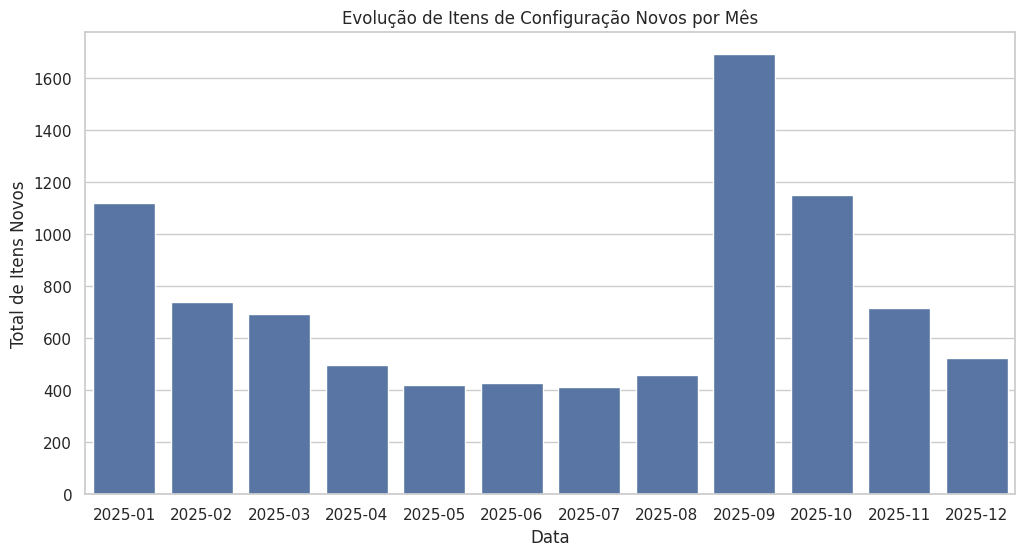

In [175]:
# Gráfico de barras (evolução de itens de configuração novos por dia)
plt.figure(figsize=(12, 6))
sns.barplot(data=itens_novos_por_mes, x=itens_novos_por_mes.index, y='total_itens_novos')
plt.title("Evolução de Itens de Configuração Novos por Mês")
plt.xlabel("Data")
plt.ylabel("Total de Itens Novos")
plt.show()

In [176]:
# Adicionando flag inativo para itens de configuração
itens_config['inativo'] = (itens_config['data_maxima'] < df_diario['data'].max() - pd.Timedelta(days=30)).astype(int)

In [177]:
# filtrando itens realmente inativos (sem incidentes nos últimos 30 dias)
itens_config.loc[itens_config['inativo'] == 1]['ciclo_vida_dias'].describe()

,ciclo_vida_dias
count,6978.000000
mean,50.233161
std,94.724137
min,0.000000
25%,0.000000
50%,0.000000
75%,56.000000
max,1042.000000


In [178]:
itens_inativos_por_dia = itens_config[itens_config['inativo'] == 1].groupby('data_maxima').agg(
    total_itens_inativos=('Item de configuração', 'count')
)

In [179]:
# Merge com df_diario para análise de comportamento de itens de configuração inativos
df_diario = df_diario.merge(itens_inativos_por_dia, left_on='data', right_index=True, how='left')

In [180]:
df_diario['total_itens_inativos'] = df_diario['total_itens_inativos'].fillna(0).astype(int)

In [181]:
itens_inativos_por_mes = df_diario.loc[df_diario['comportamento'] > 1].groupby('ano_mes').agg(
    total_itens_inativos=('total_itens_inativos', 'sum')
)

In [182]:
itens_inativos_por_mes.head()

,total_itens_inativos
ano_mes,
2025-01,378
2025-02,284
2025-03,336
2025-04,308
2025-05,296


###### Gráfico: Itens Ativos X Inativos

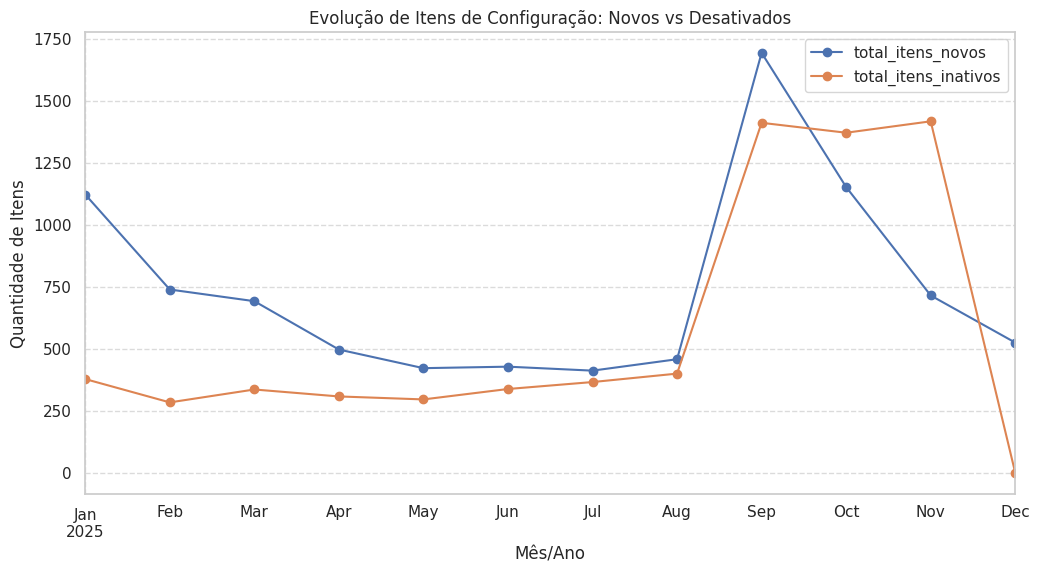

In [183]:
df_plot = pd.concat([itens_novos_por_mes, itens_inativos_por_mes], axis=1).fillna(0)
df_plot.index.name = 'Mes'
df_plot = df_plot.sort_index()

df_plot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Evolução de Itens de Configuração: Novos vs Desativados')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Itens')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [184]:
itens_config.loc[itens_config['outlier_inc_c3']==True][['Item de configuração', 'total_incidentes', 'inc_c3', 'data_minima', 'data_maxima', 'dias_ativos_c3']].sort_values('dias_ativos_c3').head(10)

,Item de configuração,total_incidentes,inc_c3,data_minima,data_maxima,dias_ativos_c3
4086,IC04105,30,14,2025-01-15,2025-10-22,1
2451,IC02460,11,9,2025-01-04,2025-11-25,1
5173,IC05205,11,11,2025-09-23,2025-09-23,1
2942,IC02955,23,23,2025-11-10,2025-11-10,1
5902,IC05935,23,23,2025-09-12,2025-09-12,1
5904,IC05937,38,23,2025-04-15,2025-09-12,1
5959,IC05993,12,9,2025-03-31,2025-09-09,1
2968,IC02981,11,10,2025-08-18,2025-11-08,1
5905,IC05938,24,23,2025-06-23,2025-09-12,1
4599,IC04627,13,13,2025-10-10,2025-10-10,1


In [185]:
itens_config.loc[itens_config['outlier_inc_c3']==True][['Item de configuração', 'total_incidentes', 'inc_c3', 'data_minima', 'data_maxima', 'dias_ativos_c3']].sort_values('dias_ativos_c3').tail(10)

,Item de configuração,total_incidentes,inc_c3,data_minima,data_maxima,dias_ativos_c3
53,IC00054,245,239,2025-01-25,2025-12-31,120
46,IC00047,156,150,2024-12-30,2025-12-31,121
99,IC00100,699,685,2025-01-26,2025-12-31,121
31,IC00032,824,823,2024-03-26,2025-12-31,121
207,IC00208,191,190,2025-06-19,2025-12-31,121
1,IC00002,3119,3119,2025-09-01,2025-12-31,122
68,IC00069,402,399,2025-02-15,2025-12-31,122
128,IC00129,246,246,2025-09-01,2025-12-31,122
18,IC00019,4435,4435,2025-09-01,2025-12-31,122
13,IC00014,6069,6069,2025-09-01,2025-12-31,122


### Cálculo de Features para o Modelo de Previsão
*Atenção com vazamento de dados - os dados de cada dia devem olhar apenas para o passado
- Abertura por (% Monitoramento por dia + agregado) - automação de abertura de incidentes
- Status (% Sem intervenção por dia + agregado) - automação de fechamento de incidentes
- Itens Config Outliers (Qtd de ICs que geram muitos incs agregado) - identificação de ICs que geram volume anormal
- Itens Config Inativados (Qtd de ICs que não geraram incs nos últimos X dias) - identificação de ICs inativados

In [186]:
df['data_encerrado'] = df['Encerrado'].dt.date
df['data_resolvido'] = df['Resolvido'].dt.date
df['data_encerrado'] = pd.to_datetime(df['data_encerrado'])
df['data_resolvido'] = pd.to_datetime(df['data_resolvido'])
df['data_encerrado'] = df['data_encerrado'].dt.normalize()
df['data_resolvido'] = df['data_resolvido'].dt.normalize()
df[['data','data_encerrado', 'data_resolvido']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 122543 entries, 122542 to 0
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   data            122543 non-null  datetime64[ns]
 1   data_encerrado  122543 non-null  datetime64[ns]
 2   data_resolvido  40241 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 7.8 MB


In [187]:
df['item_config_com_null'] = df['Item de configuração'].fillna('Sem IC')
df.loc[df['Item de configuração'].isnull()][['item_config_com_null', 'Item de configuração']].head()

,item_config_com_null,Item de configuração
122440,Sem IC,NaN
121877,Sem IC,NaN
121866,Sem IC,NaN
121843,Sem IC,NaN
121696,Sem IC,NaN


#### Monitoramento

In [188]:
# Abertura por Monitoramento
df_monitoramento = df.groupby('data').agg(
    inc_monitoramento=('Aberto por', lambda x: (x == 'Monitoramento').sum()),
).reset_index()

# Join com df_diario
df_diario = df_diario.merge(df_monitoramento, on='data', how='left')
df_diario['inc_monitoramento'] = df_diario['inc_monitoramento'].fillna(0).astype(int)

# Calculando o diario
df_diario['taxa_monitoramento_diario'] = round((df_diario['inc_monitoramento'] / df_diario['total_incidentes'])*100, 2).fillna(0)

# Calculando o acumulado mensal
df_diario['inc_ac_monitoramento_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['inc_monitoramento'].cumsum()

# Calculando o acumulado 30d (ultimos 30 dias)
df_diario['inc_ac_monitoramento_30d'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['inc_monitoramento'].transform(lambda x: x.rolling(window=30, min_periods=1).sum())

df_diario['taxa_monitoramento_ac_mes'] = round((df_diario['inc_ac_monitoramento_mes']/ df_diario['inc_ac_mes'])*100, 2).fillna(0)

# Calculando o acumulado geral
df_diario['inc_ac_monitoramento_geral'] = df_diario['inc_monitoramento'].cumsum()
df_diario['inc_ac_geral'] = df_diario['total_incidentes'].cumsum()
df_diario['taxa_monitoramento_ac_geral'] = round((df_diario['inc_ac_monitoramento_geral'] / df_diario['inc_ac_geral']) * 100, 2).fillna(0)

In [189]:
df_diario[['data','total_incidentes', 'inc_monitoramento', 'taxa_monitoramento_diario', 'inc_ac_monitoramento_mes', 'taxa_monitoramento_ac_mes','inc_ac_monitoramento_geral', 'inc_ac_geral','taxa_monitoramento_ac_geral']].tail(20)

,data,total_incidentes,inc_monitoramento,taxa_monitoramento_diario,inc_ac_monitoramento_mes,taxa_monitoramento_ac_mes,inc_ac_monitoramento_geral,inc_ac_geral,taxa_monitoramento_ac_geral
1075,2025-12-12,727,696,95.74,9106,95.49,86898,104758,82.95
1076,2025-12-13,761,749,98.42,9855,95.71,87647,105519,83.06
1077,2025-12-14,695,690,99.28,10545,95.93,88337,106214,83.17
1078,2025-12-15,863,802,92.93,11347,95.71,89139,107077,83.25
1079,2025-12-16,1076,1033,96.00,12380,95.74,90172,108153,83.37
1080,2025-12-17,1025,990,96.59,13370,95.80,91162,109178,83.50
1081,2025-12-18,1005,964,95.92,14334,95.81,92126,110183,83.61
1082,2025-12-19,839,808,96.31,15142,95.84,92934,111022,83.71
1083,2025-12-20,984,971,98.68,16113,96.00,93905,112006,83.84
1084,2025-12-21,1104,1099,99.55,17212,96.22,95004,113110,83.99


In [190]:
s_monitoramento = df_diario[[
    'data',

    # Visao Diaria
    'total_incidentes',
    'inc_monitoramento',
    'taxa_monitoramento_diario',

    # Visao Mensal Acumulada
    'inc_ac_mes',
    'inc_ac_monitoramento_mes',
    'taxa_monitoramento_ac_mes',

    # Visao Geral Acumulada
    'inc_ac_geral',
    'inc_ac_monitoramento_geral',
    'taxa_monitoramento_ac_geral',

]]
s_monitoramento.rename(columns={
    "data": "data",
    "total_incidentes": "inc",
    "inc_monitoramento": "inc_mon",
    "inc_ac_monitoramento_mes": "inc_ac_mon_mes",
    "inc_ac_monitoramento_geral": "inc_ac_mon_geral",
    "taxa_monitoramento_diario": "taxa_mon_diario",
    "taxa_monitoramento_ac_mes": "taxa_mon_ac_mes",
    "taxa_monitoramento_ac_geral": "taxa_mon_ac_geral",
}, inplace=True)
s_monitoramento.to_csv(f"{SAVE_PATH}s_diario_monitoramento.csv", index=False, sep=";", encoding="ISO-8859-1")

/tmp/ipykernel_4068/4041543737.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Status

In [191]:

# Status
df_fechamento = df.groupby('data_encerrado').agg(
    total_incidentes_encerrados=('Número', 'count'),
    inc_stat_ea=('Status', lambda x: (x == 'Encerrado Automaticamente').sum()),
    inc_stat_e=('Status', lambda x: (x == 'Encerrado').sum()),
    inc_stat_si=('Status', lambda x: (x == 'Sem Intervenção').sum())
).reset_index()

# Join com df_diario
df_diario = df_diario.merge(df_fechamento, right_on='data_encerrado', left_on='data', how='left')
df_diario = df_diario.drop(columns=['data_encerrado'])

df_diario['total_incidentes_encerrados'] = df_diario['total_incidentes_encerrados'].fillna(0).astype(int)
df_diario['inc_stat_ea'] = df_diario['inc_stat_ea'].fillna(0).astype(int)
df_diario['inc_stat_e'] = df_diario['inc_stat_e'].fillna(0).astype(int)
df_diario['inc_stat_si'] = df_diario['inc_stat_si'].fillna(0).astype(int)


# Calculando o diario
df_diario['taxa_stat_e_diario'] = round((df_diario['inc_stat_e'] / df_diario['total_incidentes_encerrados'])*100, 2).fillna(0)
df_diario['taxa_stat_ea_diario'] = round((df_diario['inc_stat_ea'] / df_diario['total_incidentes_encerrados'])*100, 2).fillna(0)
df_diario['taxa_stat_si_diario'] = round((df_diario['inc_stat_si'] / df_diario['total_incidentes_encerrados'])*100, 2).fillna(0)


# Calculando o acumulado mensal
df_diario['inc_ac_stat_e_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['inc_stat_e'].cumsum()

df_diario['inc_ac_stat_ea_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['inc_stat_ea'].cumsum()

df_diario['inc_ac_stat_si_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['inc_stat_si'].cumsum()

df_diario['inc_ac_encerrado_mes'] = df_diario.groupby([
    df_diario['data'].dt.year,
    df_diario['data'].dt.month
])['total_incidentes_encerrados'].cumsum()

df_diario['taxa_stat_e_mes'] = round((df_diario['inc_ac_stat_e_mes']/ df_diario['inc_ac_encerrado_mes'])*100, 2).fillna(0)
df_diario['taxa_stat_ea_mes'] = round((df_diario['inc_ac_stat_ea_mes']/ df_diario['inc_ac_encerrado_mes'])*100, 2).fillna(0)
df_diario['taxa_stat_si_mes'] = round((df_diario['inc_ac_stat_si_mes']/ df_diario['inc_ac_encerrado_mes'])*100, 2).fillna(0)

# Calculando o acumulado geral
df_diario['inc_ac_encerrados_geral'] = df_diario['total_incidentes_encerrados'].cumsum()
df_diario['inc_ac_stat_e_geral'] = df_diario['inc_stat_e'].cumsum()
df_diario['inc_ac_stat_ea_geral'] = df_diario['inc_stat_ea'].cumsum()
df_diario['inc_ac_stat_si_geral'] = df_diario['inc_stat_si'].cumsum()

df_diario['taxa_stat_e_geral'] = round((df_diario['inc_ac_stat_e_geral'] / df_diario['inc_ac_encerrados_geral']) * 100, 2).fillna(0)
df_diario['taxa_stat_ea_geral'] = round((df_diario['inc_ac_stat_ea_geral'] / df_diario['inc_ac_encerrados_geral']) * 100, 2).fillna(0)
df_diario['taxa_stat_si_geral'] = round((df_diario['inc_ac_stat_si_geral'] / df_diario['inc_ac_encerrados_geral']) * 100, 2).fillna(0)

In [192]:
df_diario[[
    'data',
    'total_incidentes_encerrados',

    # Visão Diária
    'inc_stat_ea',
    'taxa_stat_ea_diario',

    # Visão Acumulada no Mês
    'inc_ac_encerrado_mes',
    'inc_ac_stat_ea_mes',
    'taxa_stat_ea_mes',

    # Visão Acumulada Geral
    'inc_ac_encerrados_geral',
    'inc_ac_stat_ea_geral',
    'taxa_stat_ea_geral'
]].tail(20)

,data,total_incidentes_encerrados,inc_stat_ea,taxa_stat_ea_diario,inc_ac_encerrado_mes,inc_ac_stat_ea_mes,taxa_stat_ea_mes,inc_ac_encerrados_geral,inc_ac_stat_ea_geral,taxa_stat_ea_geral
1075,2025-12-12,735,31,4.22,9580,793,8.28,103781,25338,24.41
1076,2025-12-13,766,84,10.97,10346,877,8.48,104547,25422,24.32
1077,2025-12-14,788,74,9.39,11134,951,8.54,105335,25496,24.20
1078,2025-12-15,856,71,8.29,11990,1022,8.52,106191,25567,24.08
1079,2025-12-16,1149,90,7.83,13139,1112,8.46,107340,25657,23.90
1080,2025-12-17,995,54,5.43,14134,1166,8.25,108335,25711,23.73
1081,2025-12-18,954,23,2.41,15088,1189,7.88,109289,25734,23.55
1082,2025-12-19,1123,361,32.15,16211,1550,9.56,110412,26095,23.63
1083,2025-12-20,1032,103,9.98,17243,1653,9.59,111444,26198,23.51
1084,2025-12-21,1186,80,6.75,18429,1733,9.40,112630,26278,23.33


In [193]:
s_fechamento = df_diario[[
    'data',
    'total_incidentes_encerrados',

    # Visão Diária
    'inc_stat_ea',
    'inc_stat_e',
    'inc_stat_si',
    'taxa_stat_ea_diario',
    'taxa_stat_e_diario',
    'taxa_stat_si_diario',

    # Visão Acumulada no Mês
    'inc_ac_mes',
    'inc_ac_encerrado_mes',
    'inc_ac_stat_ea_mes',
    'inc_ac_stat_e_mes',
    'inc_ac_stat_si_mes',
    'taxa_stat_ea_mes',
    'taxa_stat_e_mes',
    'taxa_stat_si_mes',

    # Visão Acumulada Geral
    'inc_ac_geral',
    'inc_ac_encerrados_geral',
    'inc_ac_stat_ea_geral',
    'inc_ac_stat_si_geral',
    'inc_ac_stat_e_geral',
    'taxa_stat_ea_geral',
    'taxa_stat_e_geral',
    'taxa_stat_si_geral'
]]
s_fechamento.rename(columns={
    "total_incidentes_encerrados": "inc_encerrados",
}, inplace=True)
s_fechamento.to_csv(f"{SAVE_PATH}s_diario_fechamento.csv", index=False, sep=";", encoding="ISO-8859-1")

/tmp/ipykernel_4068/724179252.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Itens de configuração

In [194]:
# Agrupar incidentes por Data e IC

df_ics = (
    df.groupby(["data", "Item de configuração"])
    .agg(
        total_incidentes=("Número", "count"),
    )
    .reset_index()
)
df_ics["data"] = pd.to_datetime(df_ics["data"])

# Descobrir a data da primeira aparição de cada IC
df_grid = df_ics.groupby("Item de configuração")["data"].min().reset_index()
df_grid.rename(columns={"data": "primeira_data"}, inplace=True)

data_maxima = df_ics["data"].max()

# Criar uma série temporal contínua (lista de datas) para cada IC
df_grid["data"] = df_grid["primeira_data"].apply(
    lambda x: pd.date_range(start=x, end=data_maxima, freq="D")
)
df_grid = (
    df_grid.explode("data").drop(columns=["primeira_data"]).reset_index(drop=True)
)

# Unir o grid contínuo com os dados de incidentes e preencher dias vazios
df_ics_completo = pd.merge(
    df_grid, df_ics, on=["Item de configuração", "data"], how="left"
)
df_ics_completo["total_incidentes"] = (
    df_ics_completo["total_incidentes"].fillna(0).astype(int)
)
df_ics_completo = df_ics_completo.sort_values(
    ["Item de configuração", "data"]
).reset_index(drop=True)

# Garantir histórico anterior (shift de 1) para não vazar dado do dia atual
df_ics_completo["hist_incidentes"] = df_ics_completo.groupby("Item de configuração")[
    "total_incidentes"
].shift(1)

# Calcular a soma de incidentes nos ÚLTIMOS 50 DIAS (até D-1)
df_ics_completo["incidentes_50d_anteriores"] = (
    df_ics_completo.groupby("Item de configuração")["hist_incidentes"]
    .rolling(window=50, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
    .fillna(0)
)

# Calcular Q1, Q3 e IQR por DATA (apenas para ICs que tiveram atividade nos últimos 50 dias)
# Isso evita que uma massa de ICs com valor 0 distorça os quartis para zero.
ics_ativos = df_ics_completo[df_ics_completo["incidentes_50d_anteriores"] > 0]

iqr_por_data = (
    ics_ativos.groupby("data")["incidentes_50d_anteriores"]
    .agg(q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75))
    .reset_index()
)

iqr_por_data["iqr"] = iqr_por_data["q3"] - iqr_por_data["q1"]
iqr_por_data["limite_outlier_geral"] = iqr_por_data["q3"] + (
    1.5 * iqr_por_data["iqr"]
)

# Trazer o limite de volta para o dataframe completo
df_ics_completo = pd.merge(
    df_ics_completo,
    iqr_por_data[["data", "limite_outlier_geral"]],
    on="data",
    how="left",
)

# Aplicar a condição de Outlier
#    Um IC é outlier no dia se:
#    a) Teve atividade nos últimos 50 dias (> 0)
#    b) Sua soma dos últimos 50 dias ultrapassa o limite superior daquele dia
condicao_outlier_geral = df_ics_completo['incidentes_50d_anteriores'] > df_ics_completo['limite_outlier_geral']
condicao_atividade_recente = df_ics_completo['incidentes_50d_anteriores'] > 0

df_ics_completo['is_ic_outlier_geral'] = np.where(
    condicao_outlier_geral & condicao_atividade_recente, 1, 0
)

df_ics_completo['is_ic_inativo'] = np.where(
    ~condicao_atividade_recente, 1, 0
)

# Resultado final
ft_ic = (
    df_ics_completo.groupby('data', as_index=False)
    .agg(
        ics_outliers_ativos=('is_ic_outlier_geral', 'sum'),
        ics_inativos=('is_ic_inativo', 'sum'),
        ics_total=('Item de configuração', 'count') # Conta quantos ICs existem na base nesse dia
    )
)

In [195]:
ft_ic.tail(20)

,data,ics_outliers_ativos,ics_inativos,ics_total
1075,2025-12-12,634,5355,8881
1076,2025-12-13,630,5378,8889
1077,2025-12-14,504,5541,8893
1078,2025-12-15,501,5632,8974
1079,2025-12-16,506,5548,8999
1080,2025-12-17,512,5559,9014
1081,2025-12-18,510,5604,9041
1082,2025-12-19,515,5608,9068
1083,2025-12-20,519,5590,9075
1084,2025-12-21,515,5649,9095


In [196]:
s_ft_ic = ft_ic[[
    'data',
    'ics_outliers_ativos',
    'ics_inativos',
    'ics_total'
]]
s_ft_ic.to_csv(f"{SAVE_PATH}s_diario_itens_config.csv", index=False, sep=";", encoding="ISO-8859-1")